In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# X Axis

Pulley radius r_pulley = 0.0064 m
Base rotor inertia J_motor_datasheet = 3.400e-06 kg*m^2
Pulley radius r = 0.0064 m
Loading run 1: Responses/Processed/X/step_500.csv (kind=belt)
  -> N = 300 samples, fs ≈ 33.7 Hz
Loading run 2: Responses/Processed/X/step_1500.csv (kind=belt)
  -> N = 380 samples, fs ≈ 33.7 Hz
Loading run 3: Responses/Processed/X/step_2500.csv (kind=belt)
  -> N = 314 samples, fs ≈ 33.7 Hz
Loading run 4: Responses/Processed/X/impulse_2500.csv (kind=belt)
  -> N = 285 samples, fs ≈ 33.7 Hz
Loading run 5: Responses/Processed/X/chirp_raw.csv (kind=belt)
  -> N = 600 samples, fs ≈ 110.8 Hz
Loading run 6: Responses/Processed/motor.csv (kind=motor)
  -> N = 600 samples, fs ≈ 24.6 Hz

Free parameters: ['D_m', 'K_b', 'C_b', 'D_s', 'K_u']
Initial guess p0_free: [5.02000e-01 1.00314e+05 9.74100e+03 7.00000e+00 5.00000e-01]
Initial J_eff = alpha_J * J_motor = 0.00034 [kg*m^2]
Initial residual norm: 152.8904180795979
   Iteration     Total nfev        Cost      Cost reduction    S

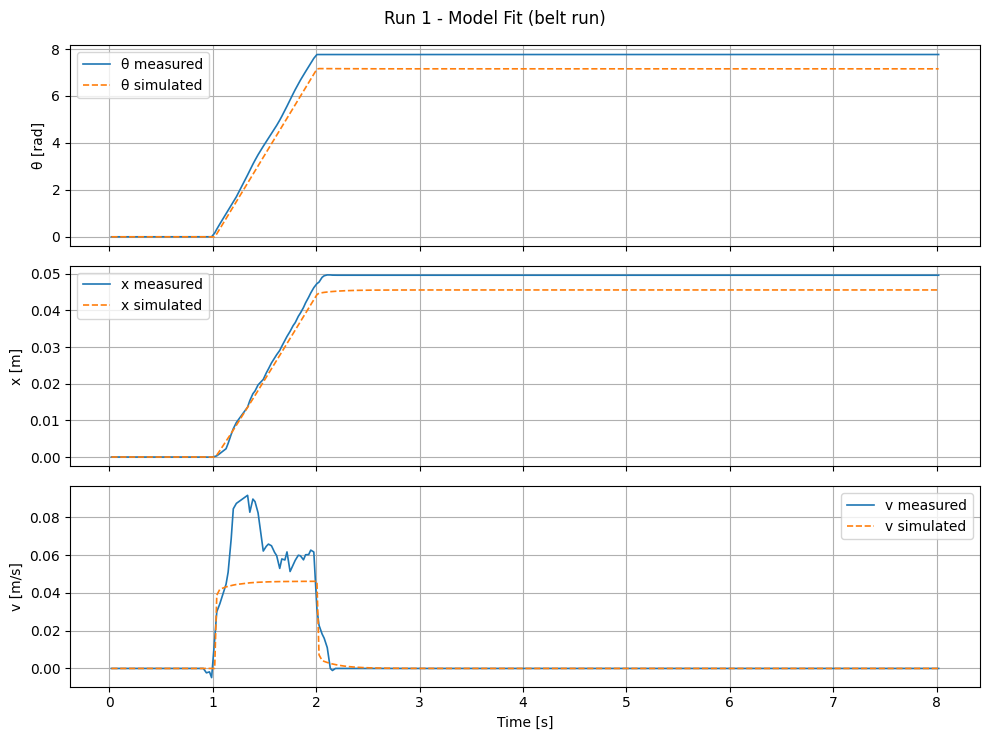


Plotting fit for run 2 (kind=belt)


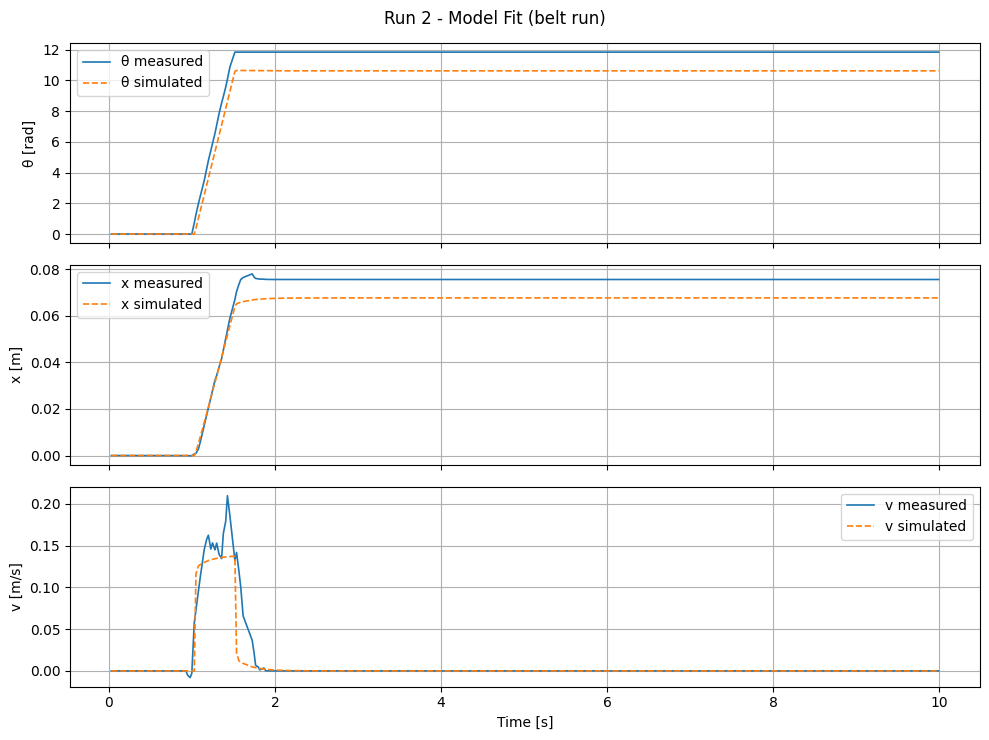


Plotting fit for run 3 (kind=belt)


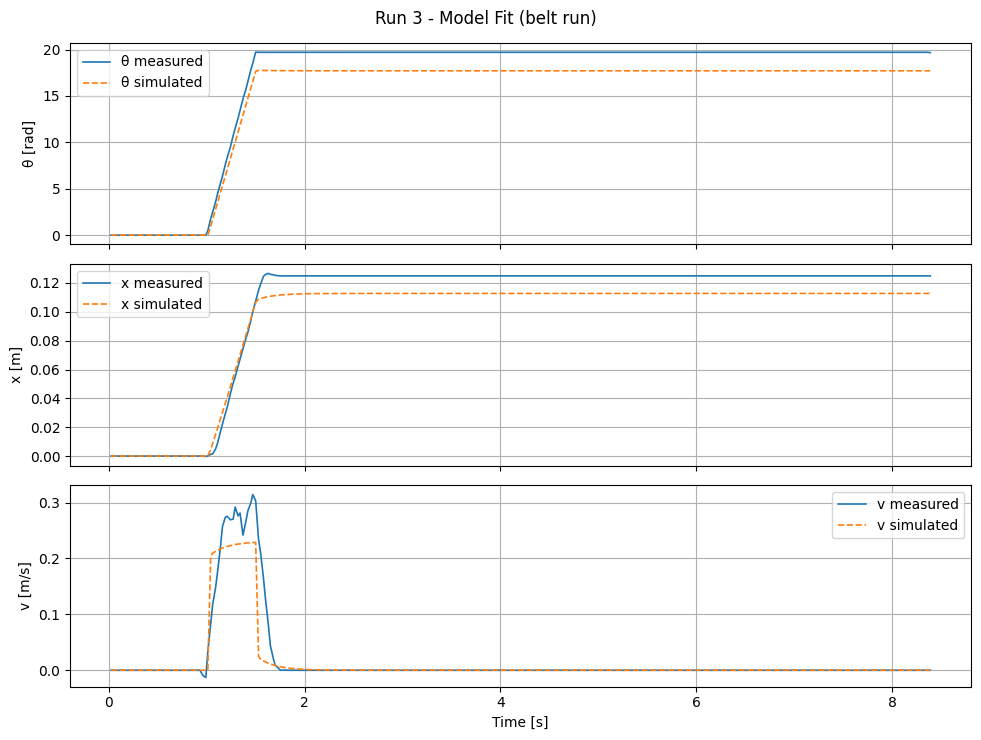


Plotting fit for run 4 (kind=belt)


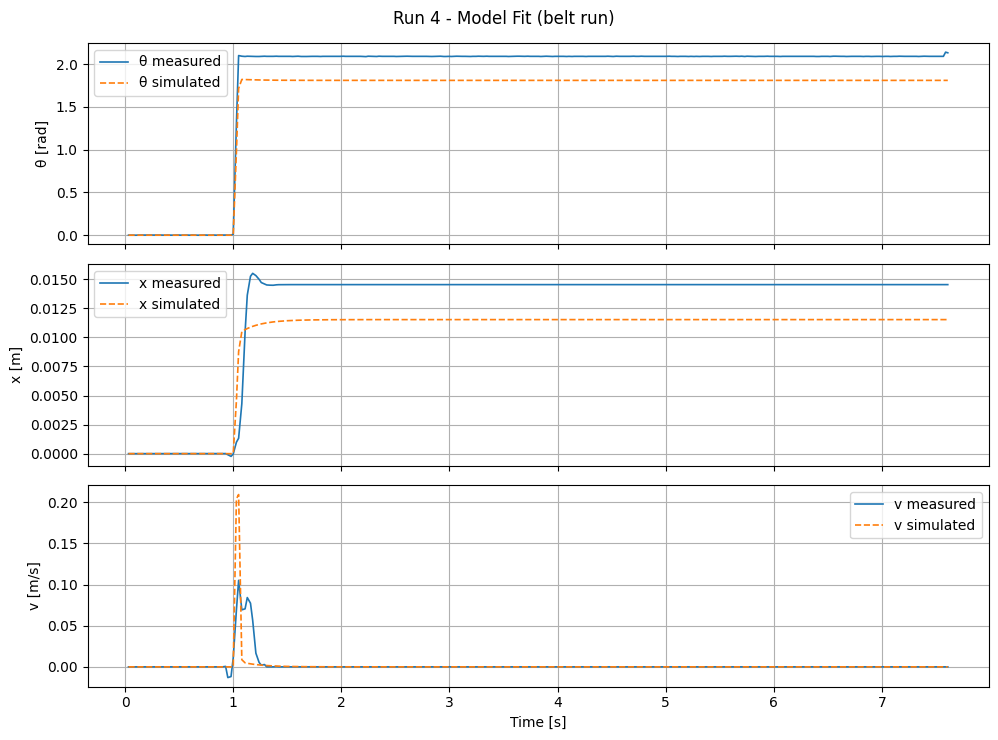


Plotting fit for run 5 (kind=belt)


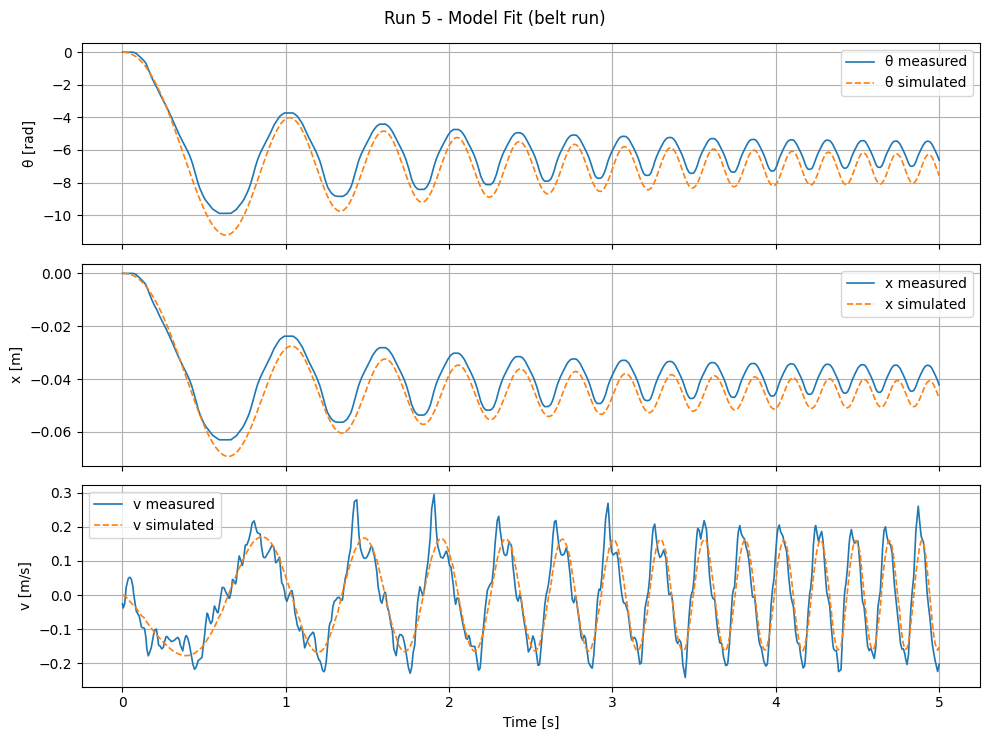


Plotting fit for run 6 (kind=motor)


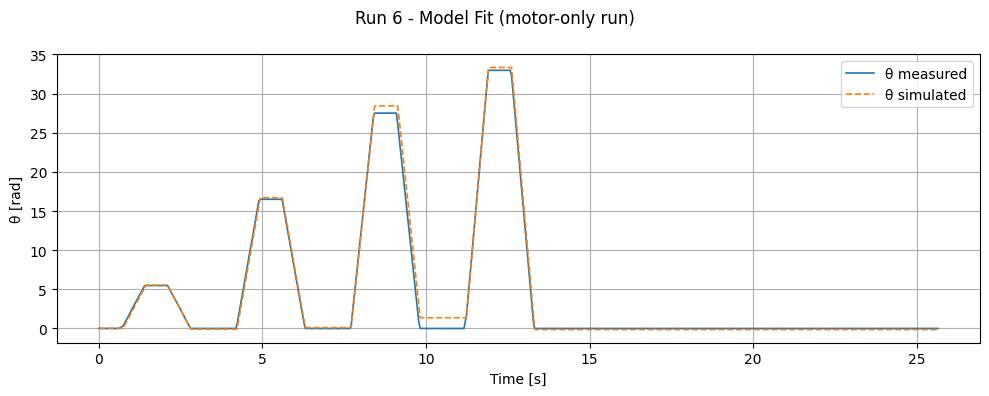

In [6]:
#!/usr/bin/env python3
"""
Flexible belt–motor–carriage identification script with joint motor-only + belt runs.

States (belt runs):
  x = [theta, dtheta, s, ds]

States (motor-only runs):
  x = [theta, dtheta]

Inputs:
  u(t): commanded motor velocity [rad/s]

Motor + belt dynamics (belt runs):
  T_m = K_u * (u - dtheta)

  J_eff * ddtheta = T_m - D_m*dtheta - r*K_b*(r*theta - s) - r*C_b*(r*dtheta - ds)

  m_cart * dds    =  r*K_b*(r*theta - s) + r*C_b*(r*dtheta - ds) - D_s*ds

Motor-only dynamics (no belt / negligible load):
  T_m = K_u * (u - dtheta)

  J_eff * ddtheta = T_m - D_m*dtheta

Effective inertia:
  J_eff = alpha_J * J_motor_datasheet

Parameters (all configurable as fixed or free):
  alpha_J : inertia scale factor [-]
  D_m     : motor damping [N*m*s/rad]
  K_b     : belt stiffness [N/m]
  C_b     : belt damping [N*s/m]
  D_s     : carriage damping [N*s/m]
  K_u     : velocity→torque gain [N*m/(rad/s)]
  m_cart  : moving mass [kg]

Control which ones are optimised by toggling the 'free' flags
in PARAM_TEMPLATE below.

Data used (per run CSV):
  - t_s          : time [s]
  - input_rad_s  : commanded motor velocity [rad/s]
  - accumulated_rad : motor angle θ [rad]
  - x_fused_m    : fused carriage position [m]
  - v_fused_m_s  : fused carriage velocity [m/s]
"""

import os
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ============================================================
# USER CONFIG
# ============================================================

# For each run - we can specify filename and kind: "motor" or "belt"
RUN_CONFIG = [
    # Belt runs (current system-id data)
    {"file": "Responses/Processed/X/step_500.csv", "kind": "belt"},
    {"file": "Responses/Processed/X/step_1500.csv", "kind": "belt"},
    {"file": "Responses/Processed/X/step_2500.csv", "kind": "belt"},
    #{"file": "Responses/Processed/X/impulse_1500.csv", "kind": "belt"},
    {"file": "Responses/Processed/X/impulse_2500.csv", "kind": "belt"},
    #{"file": "Responses/Processed/X/chirp.csv", "kind": "belt"},
    {"file": "Responses/Processed/X/chirp_raw.csv", "kind": "belt"},

    #{"file": "Responses/Processed/X/random.csv", "kind": "belt"},

    {"file": "Responses/Processed/motor.csv", "kind": "motor"},
]

DECIM_FACTOR = 2          # from ~110 Hz → ~55 Hz
MAX_SAMPLES_PER_RUN = 600

# Geometry (kept for reference; we don't use encoder→position conversion anymore)
M_PER_REV = 0.04          # 40 mm travel per revolution [m/rev]
COUNTS_PER_REV = 512
r_pulley = M_PER_REV / (2.0 * np.pi)   # [m]
print(f"Pulley radius r_pulley = {r_pulley:.4f} m")

# Base rotor inertia from datasheet
J_motor_datasheet = 3.4e-6   # [kg*m^2]

print(f"Base rotor inertia J_motor_datasheet = {J_motor_datasheet:.3e} kg*m^2")
print(f"Pulley radius r = {r_pulley:.4f} m")

# ------------------------------------------------------------
# PARAMETER TEMPLATE
#   - value: initial guess
#   - lb, ub: bounds
#   - free: True → optimised, False → fixed
# ------------------------------------------------------------

Jm_effective_old = 0.005713  # [kg*m^2] effective inertia that worked well

PARAM_TEMPLATE: Dict[str, Dict[str, Any]] = {
    # Effective inertia scale: J_eff = alpha_J * J_motor_datasheet
    "alpha_J": {
        "value": 100, #alpha_J0,
        "lb": 1.0,
        "ub": 100, #500.0,
        "free": False,   # toggle to False for J_eff to be fixed
    },

    # Motor damping
    "D_m": {
        "value": 0.002 + 0.5,
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },

    # Belt stiffness & damping
    "K_b": {
        "value": 100314,
        "lb": 1e3,
        "ub": 1e6,
        "free": True,
    },
    "C_b": {
        "value": 9741,
        "lb": 10.0,
        "ub": 5e4,
        "free": True,
    },

    # Carriage damping
    "D_s": {
        "value": 7,
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },

    # Velocity→torque gain
    "K_u": {
        "value": 0.5,
        "lb": 1e-3,
        "ub": 10.0,
        "free": True,
    },

    # Moving mass (only used in belt runs)
    "m_cart": {
        "value": 0.25,   # measured mass
        "lb": 0.02,
        "ub": 0.5,
        "free": False,   # set to True to identify mass
    },
}

# Cost weights for individual signals
w_theta = 3.0
w_x     = 3.0
w_v     = 1   # weight for velocity residuals

# Optional global weights to balance motor vs belt runs
W_MOTOR = 1.0
W_BELT  = 2.0

# Internal integration step for ode4 [s]
ODE4_H = 1e-3   # 1 ms

# ============================================================
# DATA STRUCTURE
# ============================================================

@dataclass
class RunData:
    t: np.ndarray
    u: np.ndarray
    theta: np.ndarray
    x: np.ndarray
    sigma_theta: float
    sigma_x: float
    fs: float
    kind: str              # "motor" or "belt"
    v: Optional[np.ndarray] = None   # fused velocity (for belt runs)
    sigma_v: float = 1.0             # std of v


# ============================================================
# PARAM HANDLING: FREE/FIXED MAPPING
# ============================================================

def build_free_param_vectors(
    template: Dict[str, Dict[str, Any]]
) -> Tuple[List[str], np.ndarray, np.ndarray, np.ndarray]:
    """
    From PARAM_TEMPLATE, build:
      - names_free: list of free parameter names
      - p0_free   : initial guesses for free params
      - lb_free   : lower bounds
      - ub_free   : upper bounds
    """
    names_free: List[str] = []
    p0_list: List[float] = []
    lb_list: List[float] = []
    ub_list: List[float] = []

    for name, info in template.items():
        if info.get("free", False):
            names_free.append(name)
            p0_list.append(info["value"])
            lb_list.append(info["lb"])
            ub_list.append(info["ub"])

    if not names_free:
        raise RuntimeError("No free parameters! Set at least one 'free': True.")

    return (
        names_free,
        np.array(p0_list, dtype=float),
        np.array(lb_list, dtype=float),
        np.array(ub_list, dtype=float),
    )


def params_from_free(
    p_free: np.ndarray,
    names_free: List[str],
    template: Dict[str, Dict[str, Any]],
) -> Dict[str, float]:
    """
    Construct full parameter dict {name: value} given:
      - p_free: vector of free parameter values
      - names_free: names corresponding to p_free
      - template: PARAM_TEMPLATE with 'value' for fixed params
    """
    params: Dict[str, float] = {}
    # Fill free params from p_free
    for i, name in enumerate(names_free):
        params[name] = float(p_free[i])

    # Fill fixed params from template
    for name, info in template.items():
        if not info.get("free", False):
            params[name] = float(info["value"])

    return params


def update_template_with_estimates(
    template: Dict[str, Dict[str, Any]],
    names_free: List[str],
    p_hat_free: np.ndarray
) -> Dict[str, Dict[str, Any]]:
    """
    Return a new template where the 'value' of each free parameter
    is updated with the estimated value from p_hat_free.
    """
    new_template = {k: v.copy() for k, v in template.items()}
    for name, val in zip(names_free, p_hat_free):
        new_template[name]["value"] = float(val)
    return new_template


# ============================================================
# HELPERS
# ============================================================

def thin_indices(n: int, max_n: int) -> np.ndarray:
    """Return indices that reduce length n to at most max_n."""
    if n <= max_n:
        return np.arange(n)
    return np.linspace(0, n - 1, max_n).astype(int)


# ============================================================
# LOADING CSV DATA
# ============================================================

def load_run_from_csv(fname: str, kind: str) -> RunData:
    if not os.path.exists(fname):
        raise FileNotFoundError(fname)

    df = pd.read_csv(fname)
    cols = df.columns

    # --- time ---
    if "t_s" not in cols:
        raise ValueError(f"{fname}: missing required column 't_s'")
    t = df["t_s"].to_numpy()

    # --- input u(t) in rad/s ---
    if "input_rad_s" not in cols:
        raise ValueError(f"{fname}: missing required column 'input_rad_s'")
    u = df["input_rad_s"].to_numpy()   # already rad/s

    # --- θ(t): motor angle in rad ---
    if "accumulated_rad" not in cols:
        raise ValueError(f"{fname}: missing required column 'accumulated_rad'")
    theta = df["accumulated_rad"].to_numpy()
    theta = theta - theta[0]   # normalize to start at zero

    # ------------------------------------------------------------------
    # BELT RUNS: need fused position and optional fused velocity
    # ------------------------------------------------------------------
    if kind == "belt":
        if "x_fused_m" not in cols:
            raise ValueError(f"{fname}: missing required column 'x_fused_m' for belt run")
        x = df["x_fused_m"].to_numpy()

        v = None
        sigma_v = 1.0
        if "v_fused_m_s" in cols:
            v = df["v_fused_m_s"].to_numpy()
            sigma_v = np.std(v) or 1.0

    # ------------------------------------------------------------------
    # MOTOR-ONLY RUNS: no carriage motion → we don't need x_fused or v
    # We just create dummy arrays so the dataclass stays homogeneous.
    # ------------------------------------------------------------------
    elif kind == "motor":
        # dummy "position" (not used in cost for motor runs)
        x = np.zeros_like(theta)
        v = None
        sigma_v = 1.0

    else:
        raise ValueError(f"{fname}: unknown run kind '{kind}'")

    # --- decimate ---
    if DECIM_FACTOR > 1:
        idx = np.arange(0, len(t), DECIM_FACTOR)
        t = t[idx]
        u = u[idx]
        theta = theta[idx]
        x = x[idx]
        if v is not None:
            v = v[idx]

    # --- thin samples ---
    idx_thin = thin_indices(len(t), MAX_SAMPLES_PER_RUN)
    t = t[idx_thin]
    u = u[idx_thin]
    theta = theta[idx_thin]
    x = x[idx_thin]
    if v is not None:
        v = v[idx_thin]

    # --- sampling rate ---
    dt = np.diff(t)
    fs = 1.0 / np.median(dt)

    sigma_theta = np.std(theta) or 1.0
    sigma_x     = np.std(x) or 1.0   # for motor runs this is just 0 → replaced by 1.0

    return RunData(
        t=t,
        u=u,
        theta=theta,
        x=x,
        sigma_theta=sigma_theta,
        sigma_x=sigma_x,
        fs=fs,
        kind=kind,
        v=v,
        sigma_v=sigma_v,
    )


def load_all_runs(run_config: List[Dict[str, str]]) -> List[RunData]:
    runs: List[RunData] = []
    for k, cfg in enumerate(run_config, start=1):
        fname = cfg["file"]
        kind  = cfg.get("kind", "belt")  # default to 'belt' if not specified
        print(f"Loading run {k}: {fname} (kind={kind})")
        run = load_run_from_csv(fname, kind)
        print(f"  -> N = {len(run.t)} samples, fs ≈ {run.fs:.1f} Hz")
        runs.append(run)
    return runs


# ============================================================
# MODEL DYNAMICS
# ============================================================

def belt_dynamics(x: np.ndarray, par: Dict[str, float], u_val: float) -> np.ndarray:
    """
    Continuous-time dynamics for BELT runs:

      x = [theta, dtheta, s, ds]

      par: full parameter dict with keys:
           alpha_J, D_m, K_b, C_b, D_s, K_u, m_cart
    """
    alpha_J = par["alpha_J"]
    D_m     = par["D_m"]
    K_b     = par["K_b"]
    C_b     = par["C_b"]
    D_s     = par["D_s"]
    K_u     = par["K_u"]
    m_cart  = par["m_cart"]

    # Effective inertia at the rotor:
    J_eff = alpha_J * J_motor_datasheet

    theta, dtheta, s, ds = x

    # Velocity-like motor behaviour: torque on velocity error
    T_m = K_u * u_val
    #T_m = K_u * (u_val - dtheta)

    spring = r_pulley * K_b * (r_pulley*theta - s)
    damper = r_pulley * C_b * (r_pulley*dtheta - ds)

    ddtheta = (T_m - D_m*dtheta - spring - damper) / J_eff
    dds     = (spring + damper - D_s*ds) / m_cart

    return np.array([dtheta, ddtheta, ds, dds], dtype=float)


def motor_dynamics(x: np.ndarray, par: Dict[str, float], u_val: float) -> np.ndarray:
    """
    Continuous-time dynamics for MOTOR-ONLY runs:

      x = [theta, dtheta]

      J_eff * ddtheta = K_u * (u - dtheta) - D_m * dtheta
    """
    alpha_J = par["alpha_J"]
    D_m     = par["D_m"]
    K_u     = par["K_u"]

    J_eff = alpha_J * J_motor_datasheet

    theta, dtheta = x

    T_m     = K_u * u_val 
    ddtheta = (T_m - D_m * dtheta) / J_eff

    return np.array([dtheta, ddtheta], dtype=float)


# ============================================================
# ODE4 SIMULATORS
# ============================================================

def simulate_belt_ode4(run: RunData, par: Dict[str, float], h: float = ODE4_H) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    MATLAB-style ode4 integrator for belt runs.

    Returns theta_sim, x_sim, v_sim on run.t
    """
    t_data = run.t
    u_data = run.u

    t0 = t_data[0]
    tf = t_data[-1]

    # Internal time grid
    t_grid = np.arange(t0, tf + h, h)
    n_grid = len(t_grid)

    # State
    x = np.zeros(4, dtype=float)   # [theta, dtheta, s, ds]
    x_log = np.zeros((n_grid, 4), dtype=float)

    # Input interpolation (ZOH)
    def u_of_t(t: float) -> float:
        idx = np.searchsorted(t_data, t) - 1
        idx = np.clip(idx, 0, len(u_data) - 1)
        return u_data[idx]

    # ODE4 integration loop
    for i, t in enumerate(t_grid):
        x_log[i] = x

        if i == n_grid - 1:
            break

        ui = u_of_t(t)

        k1 = belt_dynamics(x,            par, ui)
        k2 = belt_dynamics(x + 0.5*h*k1, par, ui)
        k3 = belt_dynamics(x + 0.5*h*k2, par, ui)
        k4 = belt_dynamics(x +     h*k3, par, ui)

        x = x + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if not np.all(np.isfinite(x)):
            raise RuntimeError("State exploded in simulate_belt_ode4")

    theta_grid = x_log[:, 0]
    s_grid     = x_log[:, 2]
    v_grid     = x_log[:, 3]

    theta_sim = np.interp(t_data, t_grid, theta_grid)
    x_sim     = np.interp(t_data, t_grid, s_grid)
    v_sim     = np.interp(t_data, t_grid, v_grid)

    return theta_sim, x_sim, v_sim


def simulate_motor_ode4(run: RunData, par: Dict[str, float], h: float = ODE4_H) -> np.ndarray:
    """
    MATLAB-style ode4 integrator for motor-only runs.

    Returns theta_sim on run.t
    """
    t_data = run.t
    u_data = run.u

    t0 = t_data[0]
    tf = t_data[-1]

    # Internal time grid
    t_grid = np.arange(t0, tf + h, h)
    n_grid = len(t_grid)

    # State
    x = np.zeros(2, dtype=float)   # [theta, dtheta]
    x_log = np.zeros((n_grid, 2), dtype=float)

    # Input interpolation (ZOH)
    def u_of_t(t: float) -> float:
        idx = np.searchsorted(t_data, t) - 1
        idx = np.clip(idx, 0, len(u_data) - 1)
        return u_data[idx]

    # ODE4 integration loop
    for i, t in enumerate(t_grid):
        x_log[i] = x

        if i == n_grid - 1:
            break

        ui = u_of_t(t)

        k1 = motor_dynamics(x,            par, ui)
        k2 = motor_dynamics(x + 0.5*h*k1, par, ui)
        k3 = motor_dynamics(x + 0.5*h*k2, par, ui)
        k4 = motor_dynamics(x +     h*k3, par, ui)

        x = x + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if not np.all(np.isfinite(x)):
            raise RuntimeError("State exploded in simulate_motor_ode4")

    theta_grid = x_log[:, 0]
    theta_sim  = np.interp(t_data, t_grid, theta_grid)

    return theta_sim


# ============================================================
# COST FUNCTION
# ============================================================

def residuals_all_runs(
    p_free_vec: np.ndarray,
    names_free: List[str],
    template: Dict[str, Dict[str, Any]],
    runs: List[RunData],
    sim_kwargs: Optional[Dict[str, Any]] = None
) -> np.ndarray:
    """
    Stack residuals from all runs.

    - For belt runs: use simulate_belt_ode4 → compare θ, x, and optionally v.
    - For motor-only runs: use simulate_motor_ode4 → compare θ only.
    """
    if sim_kwargs is None:
        sim_kwargs = {}

    # Clip free parameters to bounds
    _, _, lb_free, ub_free = build_free_param_vectors(template)
    p_clipped = np.clip(p_free_vec, lb_free, ub_free)

    # Build full parameter dict
    par = params_from_free(p_clipped, names_free, template)

    e_all: List[np.ndarray] = []

    for run in runs:
        try:
            if run.kind == "belt":
                theta_sim, x_sim, v_sim = simulate_belt_ode4(run, par, **sim_kwargs)
                e_theta = (theta_sim - run.theta) / run.sigma_theta
                e_x     = (x_sim     - run.x)     / run.sigma_x

                residuals = [w_theta * e_theta, w_x * e_x]

                if run.v is not None:
                    e_v = (v_sim - run.v) / run.sigma_v
                    residuals.append(w_v * e_v)

                e_run = np.concatenate(residuals)
                e_run = W_BELT * e_run

            elif run.kind == "motor":
                theta_sim = simulate_motor_ode4(run, par, **sim_kwargs)
                e_theta   = (theta_sim - run.theta) / run.sigma_theta
                e_run     = W_MOTOR * (w_theta * e_theta)

            else:
                raise ValueError(f"Unknown run.kind = {run.kind}")

            e_all.append(e_run)

        except Exception as ex:
            # Numerical failure -> large finite penalty
            print(f"Simulation failed in cost for run kind={run.kind} (penalizing):", ex)
            return 1e6 * np.ones(10)

    if not e_all:
        return np.array([], dtype=float)

    e_stack = np.concatenate(e_all)
    if not np.all(np.isfinite(e_stack)):
        return 1e6 * np.ones(10)

    return e_stack


# ============================================================
# IDENTIFICATION
# ============================================================

def identify_parameters(runs: List[RunData], template: Dict[str, Dict[str, Any]]):
    # Build free param vectors from template
    names_free, p0_free, lb_free, ub_free = build_free_param_vectors(template)

    print("\nFree parameters:", names_free)
    print("Initial guess p0_free:", p0_free)

    # Convenience: show initial effective inertia
    if "alpha_J" in template:
        alpha_init = template["alpha_J"]["value"]
        print(f"Initial J_eff = alpha_J * J_motor = {alpha_init * J_motor_datasheet:.4g} [kg*m^2]")

    sim_kwargs = {"h": ODE4_H}

    def cost_fun(p_vec: np.ndarray) -> np.ndarray:
        return residuals_all_runs(p_vec, names_free, template, runs, sim_kwargs)

    # Check initial residuals
    e0 = cost_fun(p0_free)
    if np.all(np.isfinite(e0)):
        print("Initial residual norm:", np.linalg.norm(e0))
    else:
        print("WARNING: initial residuals not finite")

    res = least_squares(
        fun=cost_fun,
        x0=p0_free,
        bounds=(lb_free, ub_free),
        method="trf",
        max_nfev=120,
        xtol=1e-6,
        ftol=1e-6,
        gtol=1e-6,
        verbose=2,
    )

    p_hat_free = np.clip(res.x, lb_free, ub_free)
    par_hat = params_from_free(p_hat_free, names_free, template)

    print("\n===== Identification result (joint motor + belt) =====")
    print("Converged:", res.success, "status:", res.status)
    print("Message:", res.message)
    print("Residual norm:", np.linalg.norm(res.fun))

    print("\nEstimated parameters (full set):")
    for name in sorted(template.keys()):
        val = par_hat[name]
        print(f"{name:7s} = {val:.6g}")

    if "alpha_J" in par_hat:
        print(f"\nJ_eff (effective inertia) = {par_hat['alpha_J'] * J_motor_datasheet:.6g} [kg*m^2]")

    print("\nTo reuse these as initial guesses, update PARAM_TEMPLATE['name']['value'].")

    # Return both the full parameter dict and the raw least_squares result
    return par_hat, res


# ============================================================
# PLOTTING
# ============================================================

def plot_fit_for_run(par_hat: Dict[str, float], run: RunData, title_prefix: str = ""):
    """Plot measured vs simulated θ(t), x(t), and v(t) where available."""
    t = run.t

    if run.kind == "belt":
        theta_sim, x_sim, v_sim = simulate_belt_ode4(run, par_hat, h=ODE4_H)

        n_rows = 3 if run.v is not None else 2
        fig, ax = plt.subplots(n_rows, 1, figsize=(10, 2.5 * n_rows), sharex=True)
        fig.suptitle(f"{title_prefix} Model Fit (belt run)")

        if n_rows == 1:
            ax = [ax]

        # θ(t)
        ax[0].plot(t, run.theta, label='θ measured', linewidth=1.2)
        ax[0].plot(t, theta_sim, '--', label='θ simulated', linewidth=1.2)
        ax[0].set_ylabel("θ [rad]")
        ax[0].grid(True)
        ax[0].legend()

        # x(t)
        ax[1].plot(t, run.x, label='x measured', linewidth=1.2)
        ax[1].plot(t, x_sim, '--', label='x simulated', linewidth=1.2)
        ax[1].set_ylabel("x [m]")
        ax[1].grid(True)
        ax[1].legend()

        # v(t) if available
        if run.v is not None:
            ax[2].plot(t, run.v, label='v measured', linewidth=1.2)
            ax[2].plot(t, v_sim, '--', label='v simulated', linewidth=1.2)
            ax[2].set_ylabel("v [m/s]")
            ax[2].set_xlabel("Time [s]")
            ax[2].grid(True)
            ax[2].legend()
        else:
            ax[1].set_xlabel("Time [s]")

        plt.tight_layout()
        plt.show()

    elif run.kind == "motor":
        theta_sim = simulate_motor_ode4(run, par_hat, h=ODE4_H)

        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        fig.suptitle(f"{title_prefix} Model Fit (motor-only run)")

        ax.plot(t, run.theta, label='θ measured', linewidth=1.2)
        ax.plot(t, theta_sim, '--', label='θ simulated', linewidth=1.2)
        ax.set_ylabel("θ [rad]")
        ax.set_xlabel("Time [s]")
        ax.grid(True)
        ax.legend()

        plt.tight_layout()
        plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    runs = load_all_runs(RUN_CONFIG)
    par_hat, res = identify_parameters(runs, PARAM_TEMPLATE)

    for i, run in enumerate(runs):
        print(f"\nPlotting fit for run {i+1} (kind={run.kind})")
        plot_fit_for_run(par_hat, run, title_prefix=f"Run {i+1} -")

if __name__ == "__main__":
    main()

# Y Axis

Pulley radius r_pulley = 0.0013 m
Base rotor inertia J_motor_datasheet = 3.400e-06 kg*m^2
Pulley radius r = 0.0013 m
Loading run 1: Responses/Processed/Y/step_2500_y.csv (kind=belt)
  -> N = 270 samples, fs ≈ 33.7 Hz
Loading run 2: Responses/Processed/Y/impulse_2500_y.csv (kind=belt)
  -> N = 330 samples, fs ≈ 33.9 Hz
Loading run 3: Responses/Processed/Y/chirp_2500_y.csv (kind=belt)
  -> N = 445 samples, fs ≈ 33.7 Hz

Free parameters: ['D_m', 'K_b', 'C_b', 'D_s']
Initial guess p0_free: [9.604252e-01 1.003140e+05 9.741000e+03 7.000000e+00]
Initial J_eff = alpha_J * J_motor = 0.00068 [kg*m^2]
Initial residual norm: 88.60930492477101
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.9258e+03                                    3.70e+04    
       1              2         2.2069e+03      1.72e+03       2.68e+04       3.44e+02    
       2              3         2.1882e+03      1.87e+01       1.12e+04       4.44e+01  

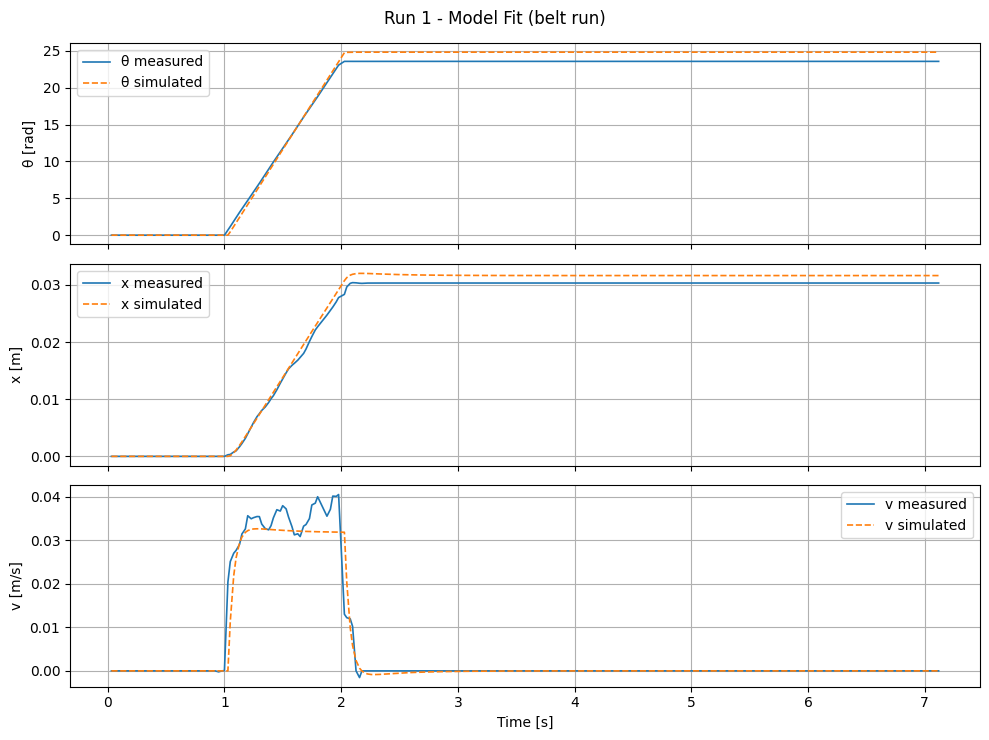


Plotting fit for run 2 (kind=belt)


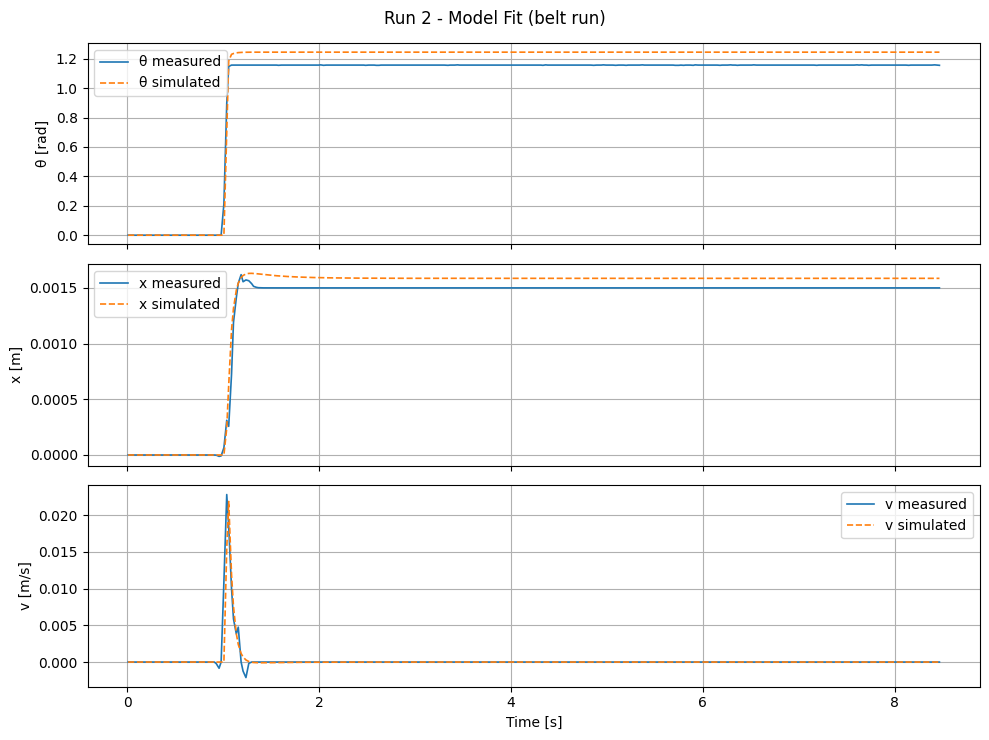


Plotting fit for run 3 (kind=belt)


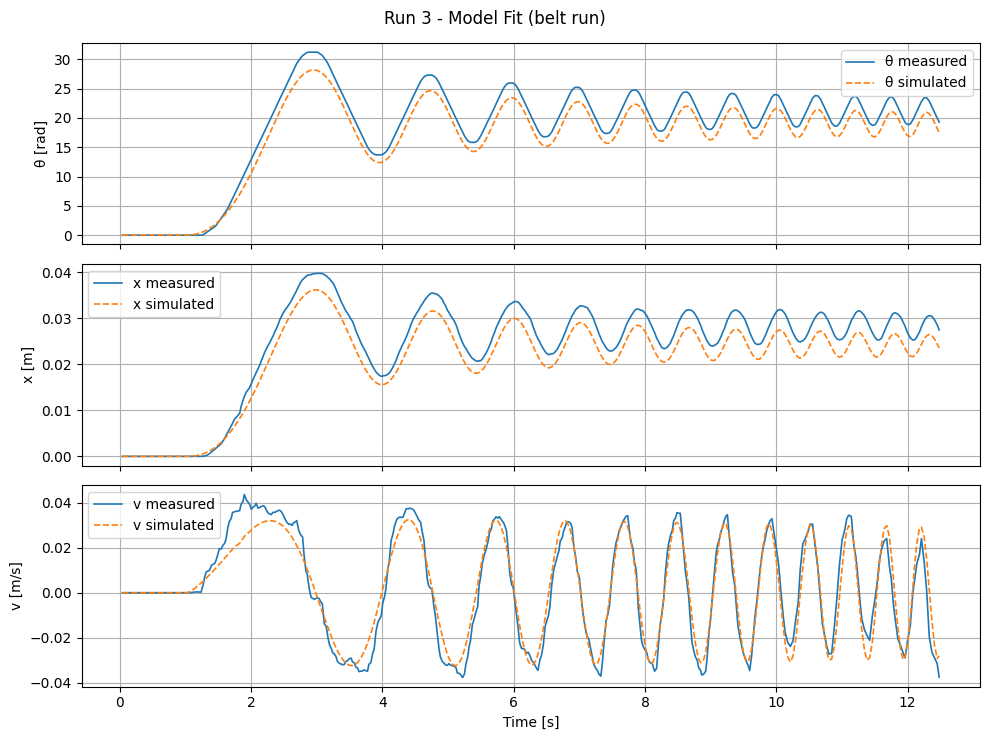

In [7]:
#!/usr/bin/env python3
"""
Flexible belt–motor–carriage identification script with joint motor-only + belt runs.

States (belt runs):
  x = [theta, dtheta, s, ds]

States (motor-only runs):
  x = [theta, dtheta]

Inputs:
  u(t): commanded motor velocity [rad/s]

Motor + belt dynamics (belt runs):
  T_m = K_u * (u - dtheta)

  J_eff * ddtheta = T_m - D_m*dtheta
                    - r*K_b*(r*theta - s)
                    - r*C_b*(r*dtheta - ds)

  m_cart * dds    =  r*K_b*(r*theta - s)
                    + r*C_b*(r*dtheta - ds)
                    - D_s*ds

Motor-only dynamics (no belt / negligible load):
  T_m = K_u * (u - dtheta)

  J_eff * ddtheta = T_m - D_m*dtheta

Effective inertia:
  J_eff = alpha_J * J_motor_datasheet

Parameters (all configurable as fixed or free):
  alpha_J : inertia scale factor [-]
  D_m     : motor damping [N*m*s/rad]
  K_b     : belt stiffness [N/m]
  C_b     : belt damping [N*s/m]
  D_s     : carriage damping [N*s/m]
  K_u     : velocity→torque gain [N*m/(rad/s)]
  m_cart  : moving mass [kg]

Control which ones are optimised by toggling the 'free' flags
in PARAM_TEMPLATE below.

Data used (per run CSV):
  - t_s          : time [s]
  - input_rad_s  : commanded motor velocity [rad/s]
  - accumulated_rad : motor angle θ [rad]
  - x_fused_m    : fused carriage position [m]
  - v_fused_m_s  : fused carriage velocity [m/s]
"""

import os
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ============================================================
# USER CONFIG
# ============================================================

# For each run, specify filename and kind: "motor" or "belt"
RUN_CONFIG = [

    # Belt runs (current system-id data)
    #{"file": "Responses/Processed/Y/step_500_y.csv", "kind": "belt"},
    {"file": "Responses/Processed/Y/step_2500_y.csv", "kind": "belt"},
    {"file": "Responses/Processed/Y/impulse_2500_y.csv", "kind": "belt"},
    {"file": "Responses/Processed/Y/chirp_2500_y.csv", "kind": "belt"},

    #{"file": "Responses/Processed/X/random.csv", "kind": "belt"},

    #{"file": "Responses/Processed/motor.csv", "kind": "motor"},
]

DECIM_FACTOR = 2          # from ~110 Hz → ~55 Hz
MAX_SAMPLES_PER_RUN = 600

# Geometry (kept for reference; we don't use encoder→position conversion anymore)
M_PER_REV = 0.008          # 8 mm travel per revolution [m/rev]
COUNTS_PER_REV = 512
r_pulley = M_PER_REV / (2.0 * np.pi)   # [m]

print(f"Pulley radius r_pulley = {r_pulley:.4f} m")

# Base rotor inertia from datasheet
J_motor_datasheet = 3.4e-6   # [kg*m^2]

print(f"Base rotor inertia J_motor_datasheet = {J_motor_datasheet:.3e} kg*m^2")
print(f"Pulley radius r = {r_pulley:.4f} m")

# ------------------------------------------------------------
# PARAMETER TEMPLATE
#   - value: initial guess
#   - lb, ub: bounds
#   - free: True → optimised, False → fixed
# ------------------------------------------------------------

Jm_effective_old = 0.005713  # [kg*m^2] effective inertia that worked well

PARAM_TEMPLATE: Dict[str, Dict[str, Any]] = {
    # Effective inertia scale: J_eff = alpha_J * J_motor_datasheet
    "alpha_J": {
        "value": 200, #alpha_J0,
        "lb": 1.0,
        "ub": 300, #500.0,
        "free": False,   # toggle to False if J_eff should be fixed
    },

    # Motor damping
    "D_m": {
        "value": 0.564956* 1.7,  # roughly double the old estimate
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },

    # Belt stiffness & damping
    "K_b": {
        "value": 100314,
        "lb": 1e3,
        "ub": 1e6,
        "free": True,
    },
    "C_b": {
        "value": 9741,
        "lb": 10.0,
        "ub": 5e4,
        "free": True,
    },

    # Carriage damping
    "D_s": {
        "value": 7,
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },

    # Velocity→torque gain
    "K_u": {
        "value": 0.567833* 2,  # roughly double the old estimate
        "lb": 1e-3,
        "ub": 10.0,
        "free": False,
    },

    # Moving mass (only used in belt runs)
    "m_cart": {
        "value": 1.156,   # measured mass
        "lb": 0.02,
        "ub": 0.5,
        "free": False,
    },
}

# Cost weights for individual signals
w_theta = 3.0
w_x     = 3.0
w_v     = 1   # weight for velocity residuals

# Optional global weights to balance motor vs belt runs
W_MOTOR = 1.0
W_BELT  = 2.0

# Internal integration step for ode4 [s]
ODE4_H = 1e-3   # 1 ms


# ============================================================
# DATA STRUCTURE
# ============================================================

@dataclass
class RunData:
    t: np.ndarray
    u: np.ndarray
    theta: np.ndarray
    x: np.ndarray
    sigma_theta: float
    sigma_x: float
    fs: float
    kind: str              # "motor" or "belt"
    v: Optional[np.ndarray] = None   # fused velocity (for belt runs)
    sigma_v: float = 1.0             # std of v


# ============================================================
# PARAM HANDLING: FREE/FIXED MAPPING
# ============================================================

def build_free_param_vectors(
    template: Dict[str, Dict[str, Any]]
) -> Tuple[List[str], np.ndarray, np.ndarray, np.ndarray]:
    """
    From PARAM_TEMPLATE, build:
      - names_free: list of free parameter names
      - p0_free   : initial guesses for free params
      - lb_free   : lower bounds
      - ub_free   : upper bounds
    """
    names_free: List[str] = []
    p0_list: List[float] = []
    lb_list: List[float] = []
    ub_list: List[float] = []

    for name, info in template.items():
        if info.get("free", False):
            names_free.append(name)
            p0_list.append(info["value"])
            lb_list.append(info["lb"])
            ub_list.append(info["ub"])

    if not names_free:
        raise RuntimeError("No free parameters! Set at least one 'free': True.")

    return (
        names_free,
        np.array(p0_list, dtype=float),
        np.array(lb_list, dtype=float),
        np.array(ub_list, dtype=float),
    )


def params_from_free(
    p_free: np.ndarray,
    names_free: List[str],
    template: Dict[str, Dict[str, Any]],
) -> Dict[str, float]:
    """
    Construct full parameter dict {name: value} given:
      - p_free: vector of free parameter values
      - names_free: names corresponding to p_free
      - template: PARAM_TEMPLATE with 'value' for fixed params
    """
    params: Dict[str, float] = {}
    # Fill free params from p_free
    for i, name in enumerate(names_free):
        params[name] = float(p_free[i])

    # Fill fixed params from template
    for name, info in template.items():
        if not info.get("free", False):
            params[name] = float(info["value"])

    return params


def update_template_with_estimates(
    template: Dict[str, Dict[str, Any]],
    names_free: List[str],
    p_hat_free: np.ndarray
) -> Dict[str, Dict[str, Any]]:
    """
    Return a new template where the 'value' of each free parameter
    is updated with the estimated value from p_hat_free.
    """
    new_template = {k: v.copy() for k, v in template.items()}
    for name, val in zip(names_free, p_hat_free):
        new_template[name]["value"] = float(val)
    return new_template


# ============================================================
# HELPERS
# ============================================================

def thin_indices(n: int, max_n: int) -> np.ndarray:
    """Return indices that reduce length n to at most max_n."""
    if n <= max_n:
        return np.arange(n)
    return np.linspace(0, n - 1, max_n).astype(int)


# ============================================================
# LOADING CSV DATA
# ============================================================

def load_run_from_csv(fname: str, kind: str) -> RunData:
    if not os.path.exists(fname):
        raise FileNotFoundError(fname)

    df = pd.read_csv(fname)
    cols = df.columns

    # --- time ---
    if "t_s" not in cols:
        raise ValueError(f"{fname}: missing required column 't_s'")
    t = df["t_s"].to_numpy()

    # --- input u(t) in rad/s ---
    if "input_rad_s" not in cols:
        raise ValueError(f"{fname}: missing required column 'input_rad_s'")
    u = df["input_rad_s"].to_numpy()  # already rad/s

    # --- θ(t): motor angle in rad ---
    if "accumulated_rad" not in cols:
        raise ValueError(f"{fname}: missing required column 'accumulated_rad'")
    theta = df["accumulated_rad"].to_numpy()
    theta = theta - theta[0]   # normalize to start at zero

    # ------------------------------------------------------------------
    # BELT RUNS: need fused position and optional fused velocity
    # ------------------------------------------------------------------
    if kind == "belt":
        if "x_fused_m" not in cols:
            raise ValueError(f"{fname}: missing required column 'x_fused_m' for belt run")
        x = df["x_fused_m"].to_numpy()

        v = None
        sigma_v = 1.0
        if "v_fused_m_s" in cols:
            v = df["v_fused_m_s"].to_numpy()
            sigma_v = np.std(v) or 1.0

    # ------------------------------------------------------------------
    # MOTOR-ONLY RUNS: no carriage motion → we don't need x_fused or v
    # We just create dummy arrays so the dataclass stays homogeneous.
    # ------------------------------------------------------------------
    elif kind == "motor":
        # dummy "position" (not used in cost for motor runs)
        x = np.zeros_like(theta)
        v = None
        sigma_v = 1.0

    else:
        raise ValueError(f"{fname}: unknown run kind '{kind}'")

    # --- decimate ---
    if DECIM_FACTOR > 1:
        idx = np.arange(0, len(t), DECIM_FACTOR)
        t = t[idx]
        u = u[idx]
        theta = theta[idx]
        x = x[idx]
        if v is not None:
            v = v[idx]

    # --- thin samples ---
    idx_thin = thin_indices(len(t), MAX_SAMPLES_PER_RUN)
    t = t[idx_thin]
    u = u[idx_thin]
    theta = theta[idx_thin]
    x = x[idx_thin]
    if v is not None:
        v = v[idx_thin]

    # --- sampling rate ---
    dt = np.diff(t)
    fs = 1.0 / np.median(dt)

    sigma_theta = np.std(theta) or 1.0
    sigma_x     = np.std(x) or 1.0   # for motor runs this is just 0 → replaced by 1.0

    return RunData(
        t=t,
        u=u,
        theta=theta,
        x=x,
        sigma_theta=sigma_theta,
        sigma_x=sigma_x,
        fs=fs,
        kind=kind,
        v=v,
        sigma_v=sigma_v,
    )


def load_all_runs(run_config: List[Dict[str, str]]) -> List[RunData]:
    runs: List[RunData] = []
    for k, cfg in enumerate(run_config, start=1):
        fname = cfg["file"]
        kind  = cfg.get("kind", "belt")  # default to 'belt' if not specified
        print(f"Loading run {k}: {fname} (kind={kind})")
        run = load_run_from_csv(fname, kind)
        print(f"  -> N = {len(run.t)} samples, fs ≈ {run.fs:.1f} Hz")
        runs.append(run)
    return runs


# ============================================================
# MODEL DYNAMICS
# ============================================================

def belt_dynamics(x: np.ndarray, par: Dict[str, float], u_val: float) -> np.ndarray:
    """
    Continuous-time dynamics for BELT runs:

      x = [theta, dtheta, s, ds]

      par: full parameter dict with keys:
           alpha_J, D_m, K_b, C_b, D_s, K_u, m_cart
    """
    alpha_J = par["alpha_J"]
    D_m     = par["D_m"]
    K_b     = par["K_b"]
    C_b     = par["C_b"]
    D_s     = par["D_s"]
    K_u     = par["K_u"]
    m_cart  = par["m_cart"]

    # Effective inertia at the rotor:
    J_eff = alpha_J * J_motor_datasheet

    theta, dtheta, s, ds = x

    # Velocity-like motor behaviour: torque on velocity error
    T_m = K_u * u_val

    spring = r_pulley * K_b * (r_pulley*theta - s)
    damper = r_pulley * C_b * (r_pulley*dtheta - ds)

    ddtheta = (T_m - D_m*dtheta - spring - damper) / J_eff
    dds     = (spring + damper - D_s*ds) / m_cart

    return np.array([dtheta, ddtheta, ds, dds], dtype=float)


def motor_dynamics(x: np.ndarray, par: Dict[str, float], u_val: float) -> np.ndarray:
    """
    Continuous-time dynamics for MOTOR-ONLY runs:

      x = [theta, dtheta]

      J_eff * ddtheta = K_u * (u - dtheta) - D_m * dtheta
    """
    alpha_J = par["alpha_J"]
    D_m     = par["D_m"]
    K_u     = par["K_u"]

    J_eff = alpha_J * J_motor_datasheet

    theta, dtheta = x

    T_m     = K_u * (u_val - dtheta)
    ddtheta = (T_m - D_m * dtheta) / J_eff

    return np.array([dtheta, ddtheta], dtype=float)


# ============================================================
# ODE4 SIMULATORS
# ============================================================

def simulate_belt_ode4(run: RunData, par: Dict[str, float], h: float = ODE4_H) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    MATLAB-style ode4 integrator for belt runs.

    Returns theta_sim, x_sim, v_sim on run.t
    """
    t_data = run.t
    u_data = run.u

    t0 = t_data[0]
    tf = t_data[-1]

    # Internal time grid
    t_grid = np.arange(t0, tf + h, h)
    n_grid = len(t_grid)

    # State
    x = np.zeros(4, dtype=float)   # [theta, dtheta, s, ds]
    x_log = np.zeros((n_grid, 4), dtype=float)

    # Input interpolation (ZOH)
    def u_of_t(t: float) -> float:
        idx = np.searchsorted(t_data, t) - 1
        idx = np.clip(idx, 0, len(u_data) - 1)
        return u_data[idx]

    # ODE4 integration loop
    for i, t in enumerate(t_grid):
        x_log[i] = x

        if i == n_grid - 1:
            break

        ui = u_of_t(t)

        k1 = belt_dynamics(x,            par, ui)
        k2 = belt_dynamics(x + 0.5*h*k1, par, ui)
        k3 = belt_dynamics(x + 0.5*h*k2, par, ui)
        k4 = belt_dynamics(x +     h*k3, par, ui)

        x = x + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if not np.all(np.isfinite(x)):
            raise RuntimeError("State exploded in simulate_belt_ode4")

    theta_grid = x_log[:, 0]
    s_grid     = x_log[:, 2]
    v_grid     = x_log[:, 3]

    theta_sim = np.interp(t_data, t_grid, theta_grid)
    x_sim     = np.interp(t_data, t_grid, s_grid)
    v_sim     = np.interp(t_data, t_grid, v_grid)

    return theta_sim, x_sim, v_sim


def simulate_motor_ode4(run: RunData, par: Dict[str, float], h: float = ODE4_H) -> np.ndarray:
    """
    MATLAB-style ode4 integrator for motor-only runs.

    Returns theta_sim on run.t
    """
    t_data = run.t
    u_data = run.u

    t0 = t_data[0]
    tf = t_data[-1]

    # Internal time grid
    t_grid = np.arange(t0, tf + h, h)
    n_grid = len(t_grid)

    # State
    x = np.zeros(2, dtype=float)   # [theta, dtheta]
    x_log = np.zeros((n_grid, 2), dtype=float)

    # Input interpolation (ZOH)
    def u_of_t(t: float) -> float:
        idx = np.searchsorted(t_data, t) - 1
        idx = np.clip(idx, 0, len(u_data) - 1)
        return u_data[idx]

    # ODE4 integration loop
    for i, t in enumerate(t_grid):
        x_log[i] = x

        if i == n_grid - 1:
            break

        ui = u_of_t(t)

        k1 = motor_dynamics(x,            par, ui)
        k2 = motor_dynamics(x + 0.5*h*k1, par, ui)
        k3 = motor_dynamics(x + 0.5*h*k2, par, ui)
        k4 = motor_dynamics(x +     h*k3, par, ui)

        x = x + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if not np.all(np.isfinite(x)):
            raise RuntimeError("State exploded in simulate_motor_ode4")

    theta_grid = x_log[:, 0]
    theta_sim  = np.interp(t_data, t_grid, theta_grid)

    return theta_sim


# ============================================================
# COST FUNCTION
# ============================================================

def residuals_all_runs(
    p_free_vec: np.ndarray,
    names_free: List[str],
    template: Dict[str, Dict[str, Any]],
    runs: List[RunData],
    sim_kwargs: Optional[Dict[str, Any]] = None
) -> np.ndarray:
    """
    Stack residuals from all runs.

    - For belt runs: use simulate_belt_ode4 → compare θ, x, and optionally v.
    - For motor-only runs: use simulate_motor_ode4 → compare θ only.
    """
    if sim_kwargs is None:
        sim_kwargs = {}

    # Clip free parameters to bounds
    _, _, lb_free, ub_free = build_free_param_vectors(template)
    p_clipped = np.clip(p_free_vec, lb_free, ub_free)

    # Build full parameter dict
    par = params_from_free(p_clipped, names_free, template)

    e_all: List[np.ndarray] = []

    for run in runs:
        try:
            if run.kind == "belt":
                theta_sim, x_sim, v_sim = simulate_belt_ode4(run, par, **sim_kwargs)
                e_theta = (theta_sim - run.theta) / run.sigma_theta
                e_x     = (x_sim     - run.x)     / run.sigma_x

                residuals = [w_theta * e_theta, w_x * e_x]

                if run.v is not None:
                    e_v = (v_sim - run.v) / run.sigma_v
                    residuals.append(w_v * e_v)

                e_run = np.concatenate(residuals)
                e_run = W_BELT * e_run

            elif run.kind == "motor":
                theta_sim = simulate_motor_ode4(run, par, **sim_kwargs)
                e_theta   = (theta_sim - run.theta) / run.sigma_theta
                e_run     = W_MOTOR * (w_theta * e_theta)

            else:
                raise ValueError(f"Unknown run.kind = {run.kind}")

            e_all.append(e_run)

        except Exception as ex:
            # Numerical failure -> large finite penalty
            print(f"Simulation failed in cost for run kind={run.kind} (penalizing):", ex)
            return 1e6 * np.ones(10)

    if not e_all:
        return np.array([], dtype=float)

    e_stack = np.concatenate(e_all)
    if not np.all(np.isfinite(e_stack)):
        return 1e6 * np.ones(10)

    return e_stack


# ============================================================
# IDENTIFICATION
# ============================================================

def identify_parameters(runs: List[RunData], template: Dict[str, Dict[str, Any]]):
    # Build free param vectors from template
    names_free, p0_free, lb_free, ub_free = build_free_param_vectors(template)

    print("\nFree parameters:", names_free)
    print("Initial guess p0_free:", p0_free)

    # Convenience: show initial effective inertia
    if "alpha_J" in template:
        alpha_init = template["alpha_J"]["value"]
        print(f"Initial J_eff = alpha_J * J_motor = {alpha_init * J_motor_datasheet:.4g} [kg*m^2]")

    sim_kwargs = {"h": ODE4_H}

    def cost_fun(p_vec: np.ndarray) -> np.ndarray:
        return residuals_all_runs(p_vec, names_free, template, runs, sim_kwargs)

    # Check initial residuals
    e0 = cost_fun(p0_free)
    if np.all(np.isfinite(e0)):
        print("Initial residual norm:", np.linalg.norm(e0))
    else:
        print("WARNING: initial residuals not finite")

    res = least_squares(
        fun=cost_fun,
        x0=p0_free,
        bounds=(lb_free, ub_free),
        method="trf",
        max_nfev=120,
        xtol=1e-6,
        ftol=1e-6,
        gtol=1e-6,
        verbose=2,
    )

    p_hat_free = np.clip(res.x, lb_free, ub_free)
    par_hat = params_from_free(p_hat_free, names_free, template)

    print("\n===== Identification result (joint motor + belt) =====")
    print("Converged:", res.success, "status:", res.status)
    print("Message:", res.message)
    print("Residual norm:", np.linalg.norm(res.fun))

    print("\nEstimated parameters (full set):")
    for name in sorted(template.keys()):
        val = par_hat[name]
        print(f"{name:7s} = {val:.6g}")

    if "alpha_J" in par_hat:
        print(f"\nJ_eff (effective inertia) = {par_hat['alpha_J'] * J_motor_datasheet:.6g} [kg*m^2]")

    print("\nTo reuse these as initial guesses, update PARAM_TEMPLATE['name']['value'].")

    # Return both the full parameter dict and the raw least_squares result
    return par_hat, res


# ============================================================
# PLOTTING
# ============================================================

def plot_fit_for_run(par_hat: Dict[str, float], run: RunData, title_prefix: str = ""):
    """Plot measured vs simulated θ(t), x(t), and v(t) where available."""
    t = run.t

    if run.kind == "belt":
        theta_sim, x_sim, v_sim = simulate_belt_ode4(run, par_hat, h=ODE4_H)

        n_rows = 3 if run.v is not None else 2
        fig, ax = plt.subplots(n_rows, 1, figsize=(10, 2.5 * n_rows), sharex=True)
        fig.suptitle(f"{title_prefix} Model Fit (belt run)")

        if n_rows == 1:
            ax = [ax]

        # θ(t)
        ax[0].plot(t, run.theta, label='θ measured', linewidth=1.2)
        ax[0].plot(t, theta_sim, '--', label='θ simulated', linewidth=1.2)
        ax[0].set_ylabel("θ [rad]")
        ax[0].grid(True)
        ax[0].legend()

        # x(t)
        ax[1].plot(t, run.x, label='x measured', linewidth=1.2)
        ax[1].plot(t, x_sim, '--', label='x simulated', linewidth=1.2)
        ax[1].set_ylabel("x [m]")
        ax[1].grid(True)
        ax[1].legend()

        # v(t) if available
        if run.v is not None:
            ax[2].plot(t, run.v, label='v measured', linewidth=1.2)
            ax[2].plot(t, v_sim, '--', label='v simulated', linewidth=1.2)
            ax[2].set_ylabel("v [m/s]")
            ax[2].set_xlabel("Time [s]")
            ax[2].grid(True)
            ax[2].legend()
        else:
            ax[1].set_xlabel("Time [s]")

        plt.tight_layout()
        plt.show()

    elif run.kind == "motor":
        theta_sim = simulate_motor_ode4(run, par_hat, h=ODE4_H)

        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        fig.suptitle(f"{title_prefix} Model Fit (motor-only run)")

        ax.plot(t, run.theta, label='θ measured', linewidth=1.2)
        ax.plot(t, theta_sim, '--', label='θ simulated', linewidth=1.2)
        ax.set_ylabel("θ [rad]")
        ax.set_xlabel("Time [s]")
        ax.grid(True)
        ax.legend()

        plt.tight_layout()
        plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    runs = load_all_runs(RUN_CONFIG)
    par_hat, res = identify_parameters(runs, PARAM_TEMPLATE)

    for i, run in enumerate(runs):
        print(f"\nPlotting fit for run {i+1} (kind={run.kind})")
        plot_fit_for_run(par_hat, run, title_prefix=f"Run {i+1} -")

if __name__ == "__main__":
    main()

# Joint test

X pulley radius r_x = 0.0064 m
Y screw equivalent radius r_y = 0.0013 m
Base rotor inertia J_motor_datasheet = 3.400e-06 kg*m^2
Loading run 1: Responses/Processed/X/step_500.csv (kind=belt, axis=x)
  -> N = 300 samples, fs ≈ 33.7 Hz
Loading run 2: Responses/Processed/X/step_1500.csv (kind=belt, axis=x)
  -> N = 380 samples, fs ≈ 33.7 Hz
Loading run 3: Responses/Processed/X/step_2500.csv (kind=belt, axis=x)
  -> N = 314 samples, fs ≈ 33.7 Hz
Loading run 4: Responses/Processed/X/impulse_2500.csv (kind=belt, axis=x)
  -> N = 285 samples, fs ≈ 33.7 Hz
Loading run 5: Responses/Processed/X/chirp_raw.csv (kind=belt, axis=x)
  -> N = 600 samples, fs ≈ 110.8 Hz
Loading run 6: Responses/Processed/motor.csv (kind=motor, axis=x)
  -> N = 600 samples, fs ≈ 24.6 Hz
Loading run 7: Responses/Processed/Y/step_2500_y.csv (kind=belt, axis=y)
  -> N = 270 samples, fs ≈ 33.7 Hz
Loading run 8: Responses/Processed/Y/impulse_2500_y.csv (kind=belt, axis=y)
  -> N = 330 samples, fs ≈ 33.9 Hz
Loading run 9: Resp

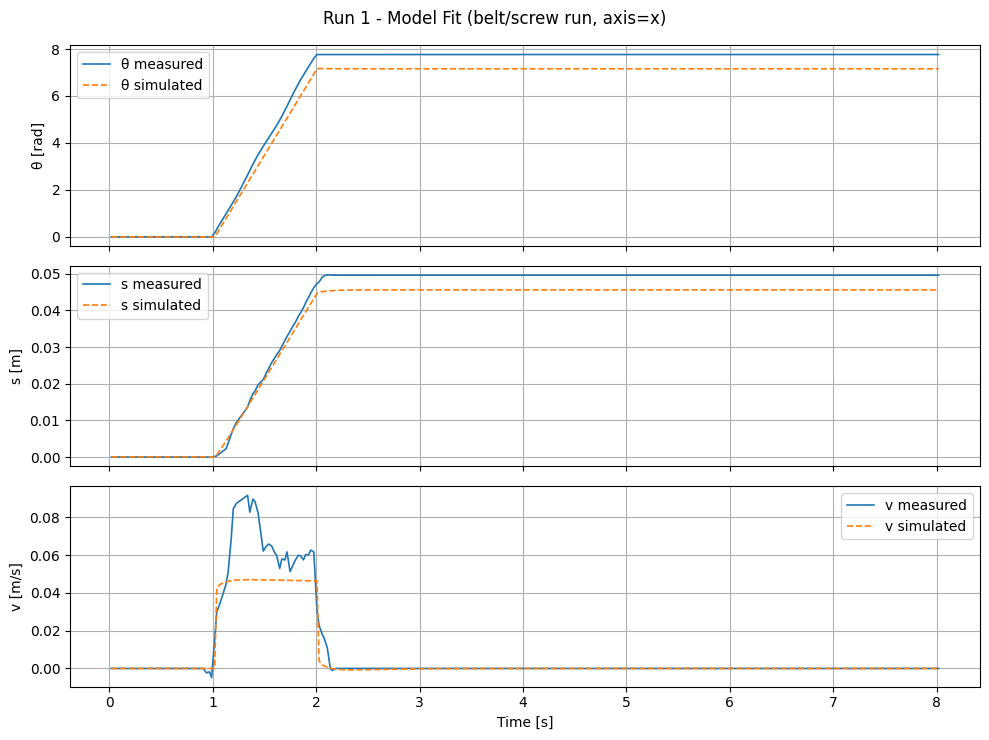


Plotting fit for run 2 (kind=belt, axis=x)


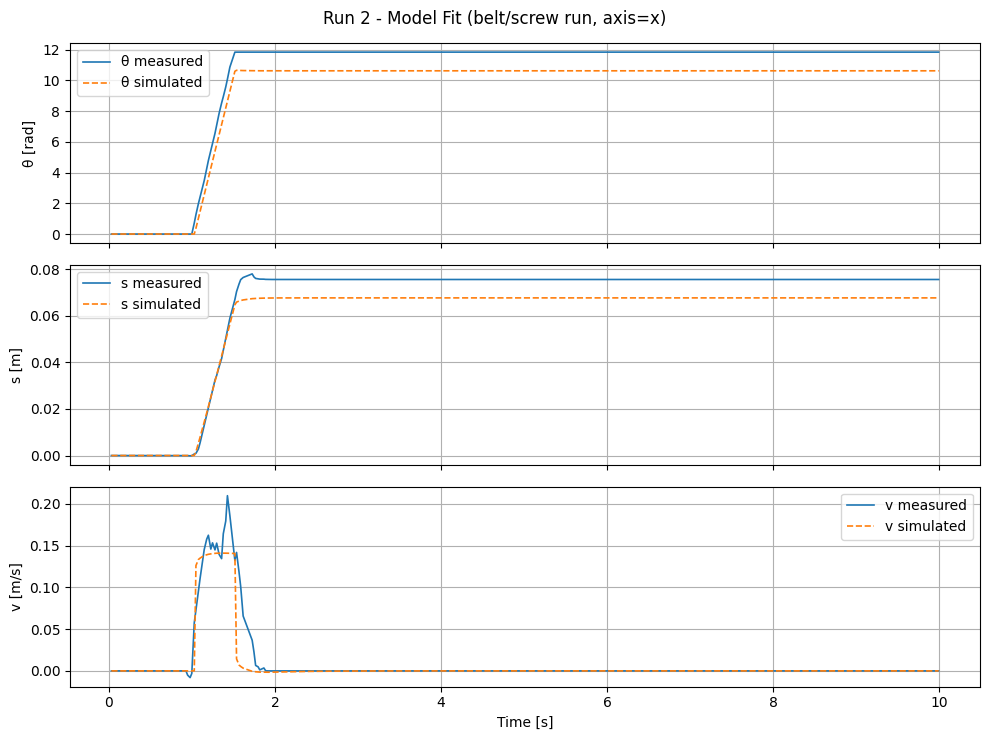


Plotting fit for run 3 (kind=belt, axis=x)


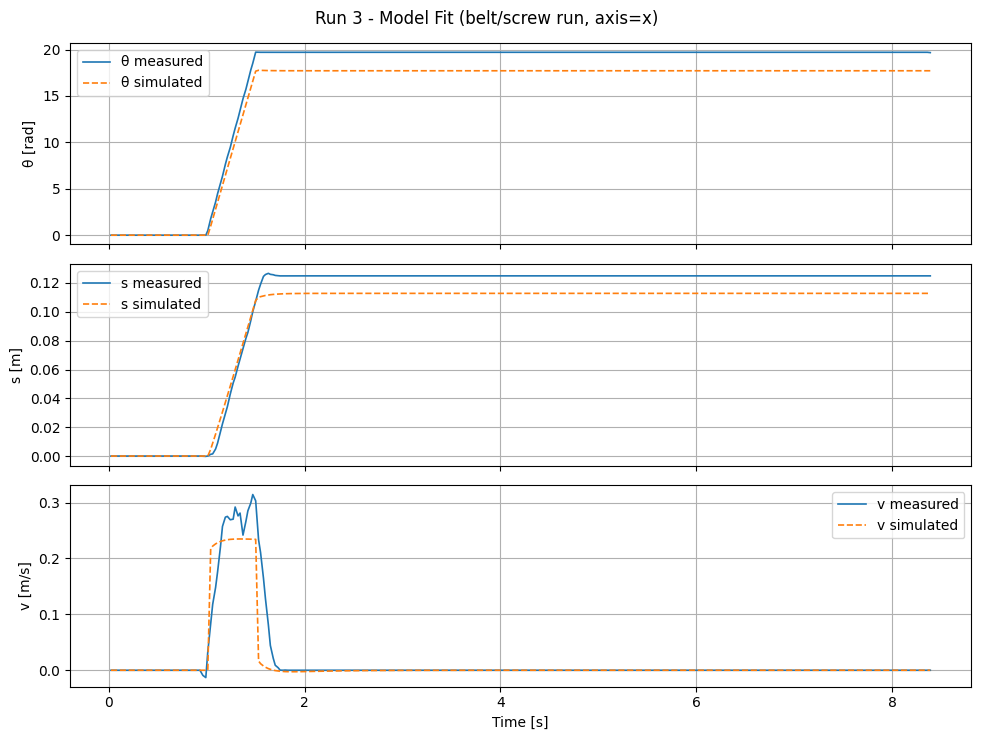


Plotting fit for run 4 (kind=belt, axis=x)


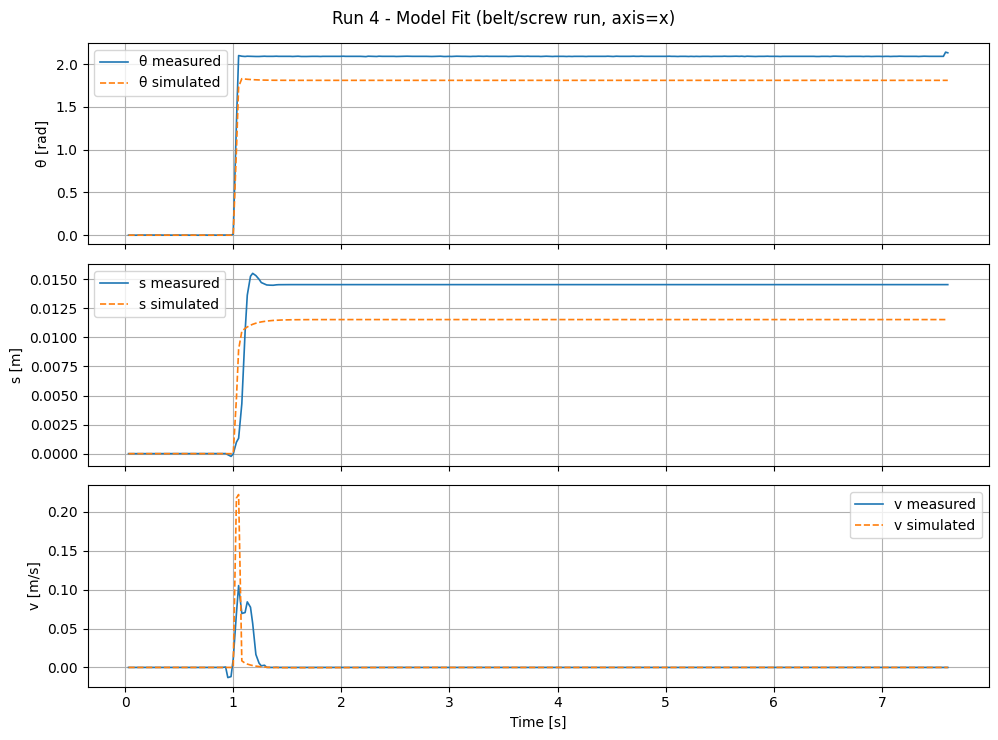


Plotting fit for run 5 (kind=belt, axis=x)


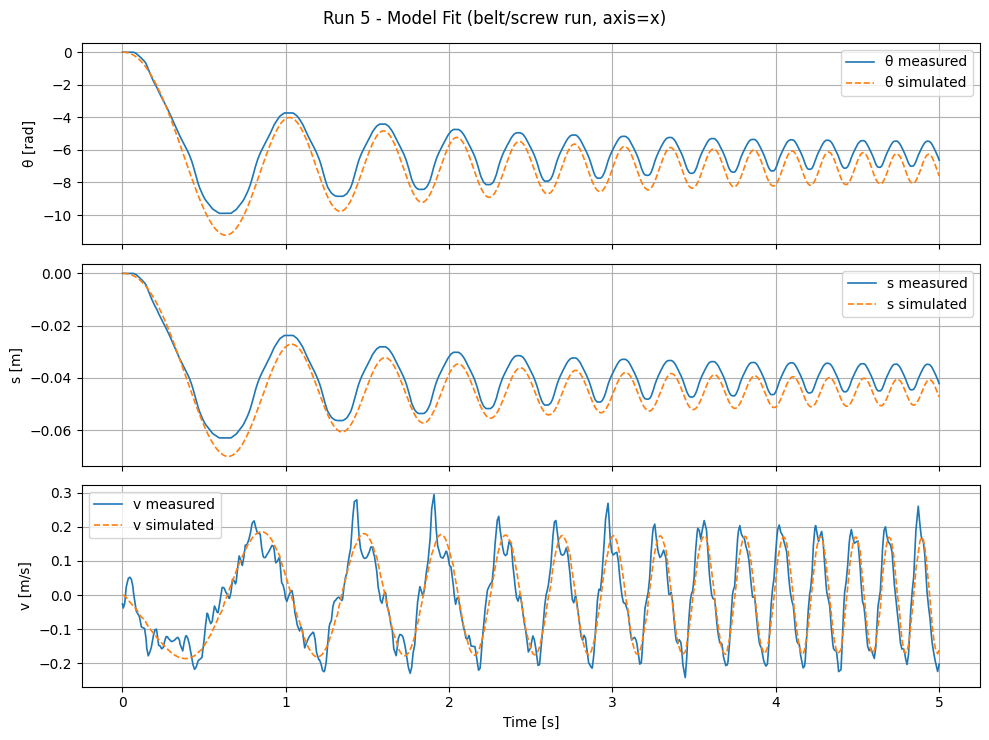


Plotting fit for run 6 (kind=motor, axis=x)


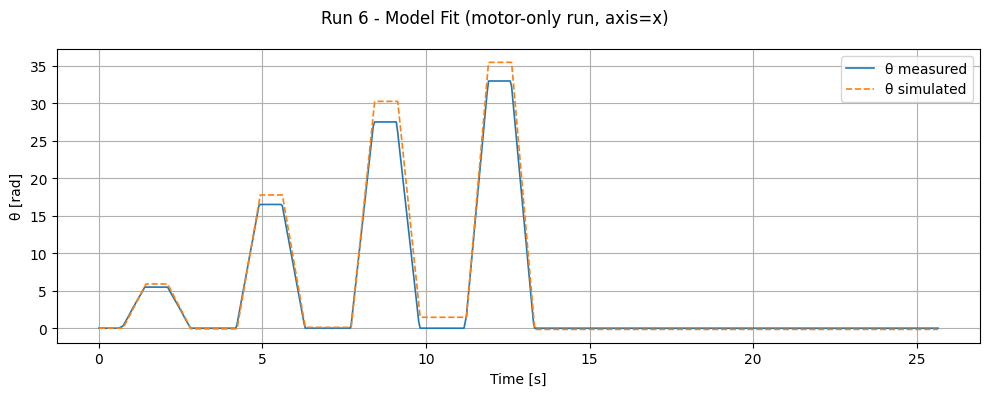


Plotting fit for run 7 (kind=belt, axis=y)


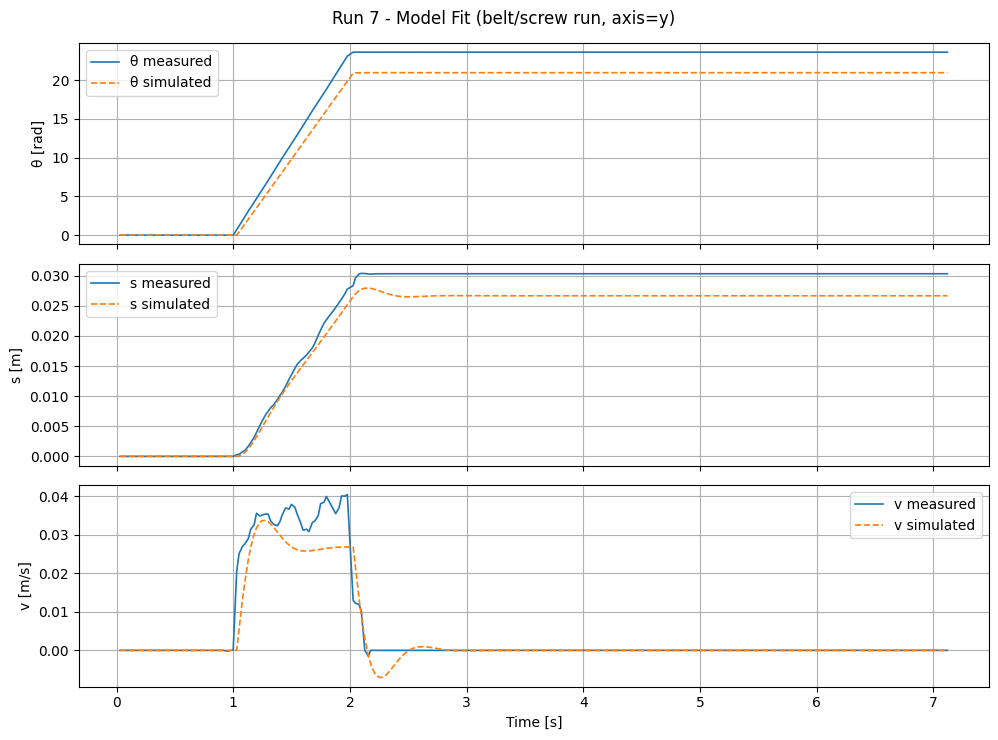


Plotting fit for run 8 (kind=belt, axis=y)


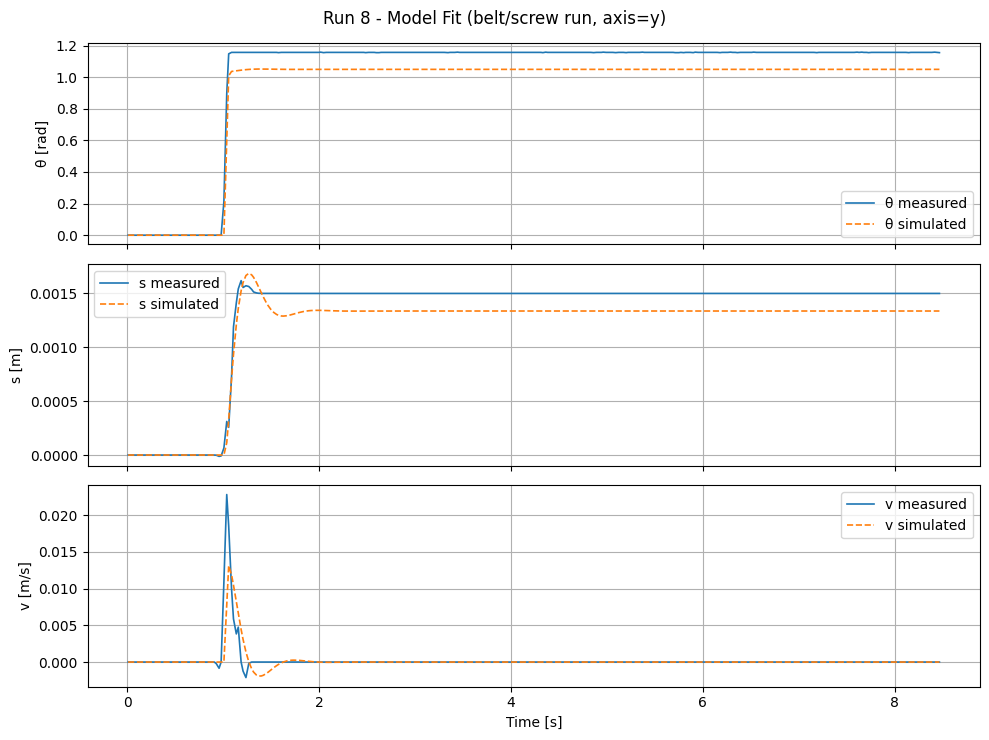


Plotting fit for run 9 (kind=belt, axis=y)


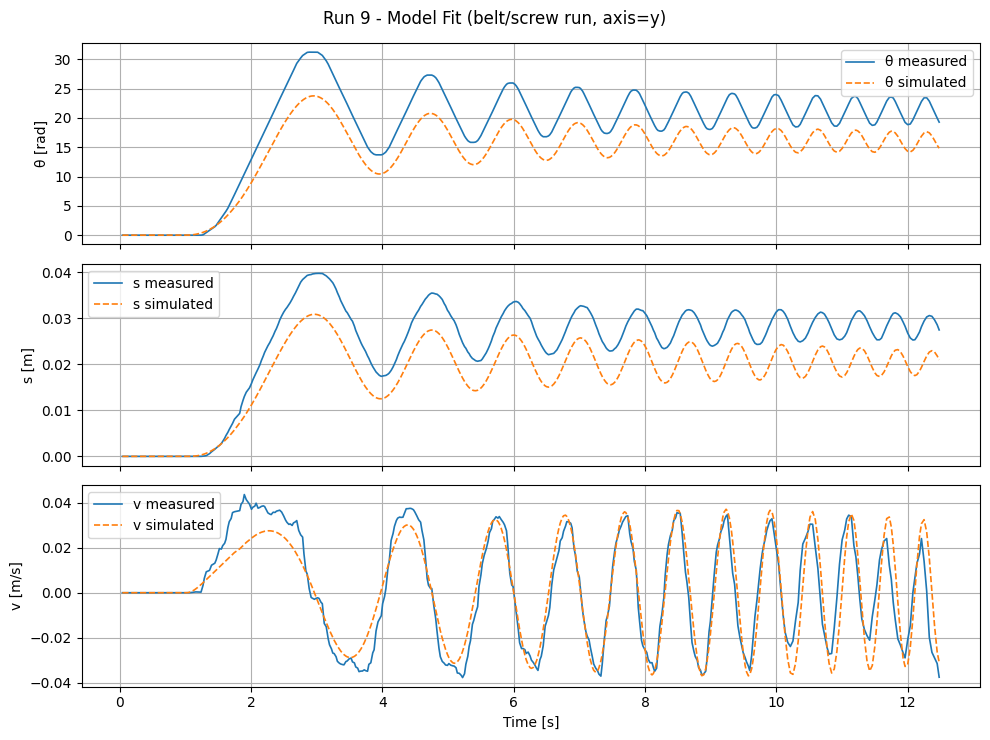

In [8]:
#!/usr/bin/env python3
"""
Joint identification script for horizontal (X) and vertical (Y) axes
with shared motor parameters and axis-specific belt/screw parameters.

States (belt runs):
  x = [theta, dtheta, s, ds]

States (motor-only runs):
  x = [theta, dtheta]

Inputs:
  u(t): commanded motor velocity [rad/s]

Motor + belt dynamics (generic axis 'a' in {x, y}):

  For X axis (single motor):
    J_eff_x = alpha_J * J_motor_datasheet
    D_m_x   = D_m
    K_u_x   = K_u

  For Y axis (two motors in parallel):
    J_eff_y = 2 * alpha_J * J_motor_datasheet
    D_m_y   = 2 * D_m
    K_u_y   = 2 * K_u

  T_m_a = K_u_a * u

  J_eff_a * ddtheta = T_m_a - D_m_a*dtheta
                      - r_a*K_b_a*(r_a*theta - s)
                      - r_a*C_b_a*(r_a*dtheta - ds)

  m_a * dds         =  r_a*K_b_a*(r_a*theta - s)
                      + r_a*C_b_a*(r_a*dtheta - ds)
                      - D_s_a*ds

Motor-only dynamics (no belt / negligible load):

  J_eff_a * ddtheta = K_u_a * u - D_m_a * dtheta

Parameters (configurable as fixed or free):

  Shared:
    alpha_J : inertia scale factor [-]
    D_m     : motor damping [N*m*s/rad]
    K_u     : velocity→torque gain [N*m/(rad/s)]

  X axis:
    K_b_x   : belt stiffness [N/m]
    C_b_x   : belt damping [N*s/m]
    D_s_x   : carriage damping [N*s/m]
    m_x     : moving mass [kg]

  Y axis:
    K_b_y   : screw stiffness [N/m]
    C_b_y   : screw damping [N*s/m]
    D_s_y   : carriage damping [N*s/m]
    m_y     : moving mass [kg]

Data used (per run CSV):
  - t_s          : time [s]
  - input_rad_s  : commanded motor velocity [rad/s]
  - accumulated_rad : motor angle θ [rad]
  - x_fused_m    : fused carriage position [m]
  - v_fused_m_s  : fused carriage velocity [m/s] (optional)
"""

import os
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ============================================================
# USER CONFIG
# ============================================================

# For each run, specify filename, kind: "motor" or "belt", and axis: "x" or "y"
RUN_CONFIG = [
    # X axis belt runs
    {"file": "Responses/Processed/X/step_500.csv",   "kind": "belt",  "axis": "x"},
    {"file": "Responses/Processed/X/step_1500.csv",  "kind": "belt",  "axis": "x"},
    {"file": "Responses/Processed/X/step_2500.csv",  "kind": "belt",  "axis": "x"},
    {"file": "Responses/Processed/X/impulse_2500.csv", "kind": "belt","axis": "x"},
    {"file": "Responses/Processed/X/chirp_raw.csv",  "kind": "belt",  "axis": "x"},

    # X axis motor-only run
    {"file": "Responses/Processed/motor.csv",        "kind": "motor", "axis": "x"},

    # Y axis belt runs
    {"file": "Responses/Processed/Y/step_2500_y.csv",   "kind": "belt", "axis": "y"},
    {"file": "Responses/Processed/Y/impulse_2500_y.csv","kind": "belt", "axis": "y"},
    {"file": "Responses/Processed/Y/chirp_2500_y.csv",  "kind": "belt", "axis": "y"},
]

DECIM_FACTOR = 2          # from ~110 Hz → ~55 Hz
MAX_SAMPLES_PER_RUN = 600

# Geometry
M_PER_REV_X = 0.04   # 40 mm travel per revolution [m/rev] - belt axis
M_PER_REV_Y = 0.008  #  8 mm travel per revolution [m/rev] - screw axis
COUNTS_PER_REV = 512

r_x = M_PER_REV_X / (2.0 * np.pi)   # [m]
r_y = M_PER_REV_Y / (2.0 * np.pi)   # [m]

print(f"X pulley radius r_x = {r_x:.4f} m")
print(f"Y screw equivalent radius r_y = {r_y:.4f} m")

# Base rotor inertia from datasheet (per motor)
J_motor_datasheet = 3.4e-6   # [kg*m^2]
print(f"Base rotor inertia J_motor_datasheet = {J_motor_datasheet:.3e} kg*m^2")

# ------------------------------------------------------------
# PARAMETER TEMPLATE
#   - value: initial guess
#   - lb, ub: bounds
#   - free: True → optimised, False → fixed
# ------------------------------------------------------------

PARAM_TEMPLATE: Dict[str, Dict[str, Any]] = {
    # Shared motor parameters (per single motor)
    "alpha_J": {
        "value": 100.0,
        "lb": 1.0,
        "ub": 500.0,
        "free": False,    # set True to identify effective inertia
    },
    "D_m": {
        "value": 0.5, 
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },
    "K_u": {
        "value": 0.5,     # shared gain; Y axis will use 2*K_u
        "lb": 1e-3,
        "ub": 10.0,
        "free": True,
    },

    # X axis (belt)
    "K_b_x": {
        "value": 1.0e5,
        "lb": 1e3,
        "ub": 1e6,
        "free": True,
    },
    "C_b_x": {
        "value": 9741.0,
        "lb": 10.0,
        "ub": 5e4,
        "free": True,
    },
    "D_s_x": {
        "value": 7.0,
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },
    "m_x": {
        "value": 0.25,
        "lb": 0.02,
        "ub": 0.5,
        "free": False,    # measured
    },

    # Y axis (screw)
    "K_b_y": {
        "value": 1.0e5,
        "lb": 1e3,
        "ub": 1e6,
        "free": True,
    },
    "C_b_y": {
        "value": 9741.0,
        "lb": 10.0,
        "ub": 5e4,
        "free": True,
    },
    "D_s_y": {
        "value": 7.0,
        "lb": 1e-4,
        "ub": 50.0,
        "free": True,
    },
    "m_y": {
        "value": 1.156,   # measured vertical moving mass
        "lb": 0.1,
        "ub": 3.0,
        "free": False,    # measured
    },
}

# Cost weights for individual signals
w_theta = 10.0
w_x     = 10.0
w_v     = 1.0   # weight for velocity residuals

# Optional global weights to balance motor vs belt runs
W_MOTOR = 5.0
W_BELT  = 1.0

# Internal integration step for ode4 [s]
ODE4_H = 1e-3   # 1 ms


# ============================================================
# DATA STRUCTURE
# ============================================================

@dataclass
class RunData:
    t: np.ndarray
    u: np.ndarray
    theta: np.ndarray
    x: np.ndarray
    sigma_theta: float
    sigma_x: float
    fs: float
    kind: str              # "motor" or "belt"
    axis: str              # "x" or "y"
    v: Optional[np.ndarray] = None   # fused velocity (for belt runs)
    sigma_v: float = 1.0             # std of v


# ============================================================
# PARAM HANDLING: FREE/FIXED MAPPING
# ============================================================

def build_free_param_vectors(
    template: Dict[str, Dict[str, Any]]
) -> Tuple[List[str], np.ndarray, np.ndarray, np.ndarray]:
    names_free: List[str] = []
    p0_list: List[float] = []
    lb_list: List[float] = []
    ub_list: List[float] = []

    for name, info in template.items():
        if info.get("free", False):
            names_free.append(name)
            p0_list.append(info["value"])
            lb_list.append(info["lb"])
            ub_list.append(info["ub"])

    if not names_free:
        raise RuntimeError("No free parameters! Set at least one 'free': True.")

    return (
        names_free,
        np.array(p0_list, dtype=float),
        np.array(lb_list, dtype=float),
        np.array(ub_list, dtype=float),
    )


def params_from_free(
    p_free: np.ndarray,
    names_free: List[str],
    template: Dict[str, Dict[str, Any]],
) -> Dict[str, float]:
    params: Dict[str, float] = {}
    for i, name in enumerate(names_free):
        params[name] = float(p_free[i])

    for name, info in template.items():
        if not info.get("free", False):
            params[name] = float(info["value"])

    return params


def update_template_with_estimates(
    template: Dict[str, Dict[str, Any]],
    names_free: List[str],
    p_hat_free: np.ndarray
) -> Dict[str, Dict[str, Any]]:
    new_template = {k: v.copy() for k, v in template.items()}
    for name, val in zip(names_free, p_hat_free):
        new_template[name]["value"] = float(val)
    return new_template


# ============================================================
# HELPERS
# ============================================================

def thin_indices(n: int, max_n: int) -> np.ndarray:
    if n <= max_n:
        return np.arange(n)
    return np.linspace(0, n - 1, max_n).astype(int)


# ============================================================
# LOADING CSV DATA
# ============================================================

def load_run_from_csv(fname: str, kind: str, axis: str) -> RunData:
    if not os.path.exists(fname):
        raise FileNotFoundError(fname)

    df = pd.read_csv(fname)
    cols = df.columns

    # time
    if "t_s" not in cols:
        raise ValueError(f"{fname}: missing required column 't_s'")
    t = df["t_s"].to_numpy()

    # input u(t) in rad/s
    if "input_rad_s" not in cols:
        raise ValueError(f"{fname}: missing required column 'input_rad_s'")
    u = df["input_rad_s"].to_numpy()

    # motor angle
    if "accumulated_rad" not in cols:
        raise ValueError(f"{fname}: missing required column 'accumulated_rad'")
    theta = df["accumulated_rad"].to_numpy()
    theta = theta - theta[0]   # normalize to start at zero

    # belt/screw runs: need carriage position and optional velocity
    if kind == "belt":
        if "x_fused_m" not in cols:
            raise ValueError(f"{fname}: missing required column 'x_fused_m' for belt run")
        x = df["x_fused_m"].to_numpy()

        v = None
        sigma_v = 1.0
        if "v_fused_m_s" in cols:
            v = df["v_fused_m_s"].to_numpy()
            sigma_v = np.std(v) or 1.0
    elif kind == "motor":
        # dummy position (not used in cost for motor runs)
        x = np.zeros_like(theta)
        v = None
        sigma_v = 1.0
    else:
        raise ValueError(f"{fname}: unknown run kind '{kind}'")

    # decimate
    if DECIM_FACTOR > 1:
        idx = np.arange(0, len(t), DECIM_FACTOR)
        t = t[idx]
        u = u[idx]
        theta = theta[idx]
        x = x[idx]
        if v is not None:
            v = v[idx]

    # thin samples
    idx_thin = thin_indices(len(t), MAX_SAMPLES_PER_RUN)
    t = t[idx_thin]
    u = u[idx_thin]
    theta = theta[idx_thin]
    x = x[idx_thin]
    if v is not None:
        v = v[idx_thin]

    dt = np.diff(t)
    fs = 1.0 / np.median(dt)

    sigma_theta = np.std(theta) or 1.0
    sigma_x     = np.std(x) or 1.0

    return RunData(
        t=t,
        u=u,
        theta=theta,
        x=x,
        sigma_theta=sigma_theta,
        sigma_x=sigma_x,
        fs=fs,
        kind=kind,
        axis=axis,
        v=v,
        sigma_v=sigma_v,
    )


def load_all_runs(run_config: List[Dict[str, str]]) -> List[RunData]:
    runs: List[RunData] = []
    for k, cfg in enumerate(run_config, start=1):
        fname = cfg["file"]
        kind  = cfg.get("kind", "belt")
        axis  = cfg.get("axis", "x")
        print(f"Loading run {k}: {fname} (kind={kind}, axis={axis})")
        run = load_run_from_csv(fname, kind, axis)
        print(f"  -> N = {len(run.t)} samples, fs ≈ {run.fs:.1f} Hz")
        runs.append(run)
    return runs


# ============================================================
# MODEL DYNAMICS
# ============================================================

def _axis_params(axis: str, par: Dict[str, float]) -> Dict[str, float]:
    """Extract effective axis-specific parameters (geometry, coupling, etc.)."""
    if axis == "x":
        r = r_x
        K_b = par["K_b_x"]
        C_b = par["C_b_x"]
        D_s = par["D_s_x"]
        m   = par["m_x"]
        J_eff = par["alpha_J"] * J_motor_datasheet
        D_m_eff = par["D_m"]
        K_u_eff = par["K_u"]
    elif axis == "y":
        r = r_y
        K_b = par["K_b_y"]
        C_b = par["C_b_y"]
        D_s = par["D_s_y"]
        m   = par["m_y"]
        # two motors in parallel
        J_eff = 2.0 * par["alpha_J"] * J_motor_datasheet
        D_m_eff = 2.0 * par["D_m"]
        K_u_eff = 2.0 * par["K_u"]
    else:
        raise ValueError(f"Unknown axis '{axis}'")

    return dict(r=r, K_b=K_b, C_b=C_b, D_s=D_s, m=m,
                J_eff=J_eff, D_m_eff=D_m_eff, K_u_eff=K_u_eff)


def belt_dynamics(axis: str, x: np.ndarray, par: Dict[str, float], u_val: float) -> np.ndarray:
    """
    Continuous-time dynamics for BELT/SCREW runs:

      x = [theta, dtheta, s, ds]
    """
    ap = _axis_params(axis, par)
    r        = ap["r"]
    K_b      = ap["K_b"]
    C_b      = ap["C_b"]
    D_s      = ap["D_s"]
    m_cart   = ap["m"]
    J_eff    = ap["J_eff"]
    D_m_eff  = ap["D_m_eff"]
    K_u_eff  = ap["K_u_eff"]

    theta, dtheta, s, ds = x

    T_m = K_u_eff * u_val

    spring = r * K_b * (r * theta - s)
    damper = r * C_b * (r * dtheta - ds)

    ddtheta = (T_m - D_m_eff * dtheta - spring - damper) / J_eff
    dds     = (spring + damper - D_s * ds) / m_cart

    return np.array([dtheta, ddtheta, ds, dds], dtype=float)


def motor_dynamics(axis: str, x: np.ndarray, par: Dict[str, float], u_val: float) -> np.ndarray:
    """
    Continuous-time dynamics for MOTOR-ONLY runs:

      x = [theta, dtheta]
    """
    ap = _axis_params(axis, par)
    J_eff    = ap["J_eff"]
    D_m_eff  = ap["D_m_eff"]
    K_u_eff  = ap["K_u_eff"]

    theta, dtheta = x

    T_m     = K_u_eff * u_val
    ddtheta = (T_m - D_m_eff * dtheta) / J_eff

    return np.array([dtheta, ddtheta], dtype=float)


# ============================================================
# ODE4 SIMULATORS
# ============================================================

def simulate_belt_ode4(run: RunData, par: Dict[str, float], h: float = ODE4_H) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    MATLAB-style ode4 integrator for belt/screw runs.

    Returns theta_sim, x_sim, v_sim on run.t
    """
    t_data = run.t
    u_data = run.u

    t0 = t_data[0]
    tf = t_data[-1]

    t_grid = np.arange(t0, tf + h, h)
    n_grid = len(t_grid)

    x = np.zeros(4, dtype=float)   # [theta, dtheta, s, ds]
    x_log = np.zeros((n_grid, 4), dtype=float)

    def u_of_t(t: float) -> float:
        idx = np.searchsorted(t_data, t) - 1
        idx = np.clip(idx, 0, len(u_data) - 1)
        return u_data[idx]

    for i, t in enumerate(t_grid):
        x_log[i] = x
        if i == n_grid - 1:
            break

        ui = u_of_t(t)

        k1 = belt_dynamics(run.axis, x,               par, ui)
        k2 = belt_dynamics(run.axis, x + 0.5*h*k1,    par, ui)
        k3 = belt_dynamics(run.axis, x + 0.5*h*k2,    par, ui)
        k4 = belt_dynamics(run.axis, x +     h*k3,    par, ui)

        x = x + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if not np.all(np.isfinite(x)):
            raise RuntimeError("State exploded in simulate_belt_ode4")

    theta_grid = x_log[:, 0]
    s_grid     = x_log[:, 2]
    v_grid     = x_log[:, 3]

    theta_sim = np.interp(t_data, t_grid, theta_grid)
    x_sim     = np.interp(t_data, t_grid, s_grid)
    v_sim     = np.interp(t_data, t_grid, v_grid)

    return theta_sim, x_sim, v_sim


def simulate_motor_ode4(run: RunData, par: Dict[str, float], h: float = ODE4_H) -> np.ndarray:
    """
    MATLAB-style ode4 integrator for motor-only runs.

    Returns theta_sim on run.t
    """
    t_data = run.t
    u_data = run.u

    t0 = t_data[0]
    tf = t_data[-1]

    t_grid = np.arange(t0, tf + h, h)
    n_grid = len(t_grid)

    x = np.zeros(2, dtype=float)   # [theta, dtheta]
    x_log = np.zeros((n_grid, 2), dtype=float)

    def u_of_t(t: float) -> float:
        idx = np.searchsorted(t_data, t) - 1
        idx = np.clip(idx, 0, len(u_data) - 1)
        return u_data[idx]

    for i, t in enumerate(t_grid):
        x_log[i] = x
        if i == n_grid - 1:
            break

        ui = u_of_t(t)

        k1 = motor_dynamics(run.axis, x,               par, ui)
        k2 = motor_dynamics(run.axis, x + 0.5*h*k1,    par, ui)
        k3 = motor_dynamics(run.axis, x + 0.5*h*k2,    par, ui)
        k4 = motor_dynamics(run.axis, x +     h*k3,    par, ui)

        x = x + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if not np.all(np.isfinite(x)):
            raise RuntimeError("State exploded in simulate_motor_ode4")

    theta_grid = x_log[:, 0]
    theta_sim  = np.interp(t_data, t_grid, theta_grid)

    return theta_sim


# ============================================================
# COST FUNCTION
# ============================================================

def residuals_all_runs(
    p_free_vec: np.ndarray,
    names_free: List[str],
    template: Dict[str, Dict[str, Any]],
    runs: List[RunData],
    sim_kwargs: Optional[Dict[str, Any]] = None
) -> np.ndarray:
    if sim_kwargs is None:
        sim_kwargs = {}

    # Clip free parameters to bounds
    _, _, lb_free, ub_free = build_free_param_vectors(template)
    p_clipped = np.clip(p_free_vec, lb_free, ub_free)

    par = params_from_free(p_clipped, names_free, template)

    e_all: List[np.ndarray] = []

    for run in runs:
        try:
            if run.kind == "belt":
                theta_sim, x_sim, v_sim = simulate_belt_ode4(run, par, **sim_kwargs)
                e_theta = (theta_sim - run.theta) / run.sigma_theta
                e_x     = (x_sim     - run.x)     / run.sigma_x

                residuals = [w_theta * e_theta, w_x * e_x]

                if run.v is not None:
                    e_v = (v_sim - run.v) / run.sigma_v
                    residuals.append(w_v * e_v)

                e_run = np.concatenate(residuals)
                e_run = W_BELT * e_run

            elif run.kind == "motor":
                theta_sim = simulate_motor_ode4(run, par, **sim_kwargs)
                e_theta   = (theta_sim - run.theta) / run.sigma_theta
                e_run     = W_MOTOR * (w_theta * e_theta)

            else:
                raise ValueError(f"Unknown run.kind = {run.kind}")

            e_all.append(e_run)

        except Exception as ex:
            print(f"Simulation failed in cost for run kind={run.kind}, axis={run.axis} (penalizing):", ex)
            return 1e6 * np.ones(10)

    if not e_all:
        return np.array([], dtype=float)

    e_stack = np.concatenate(e_all)
    if not np.all(np.isfinite(e_stack)):
        return 1e6 * np.ones(10)

    return e_stack


# ============================================================
# IDENTIFICATION
# ============================================================

def identify_parameters(runs: List[RunData], template: Dict[str, Dict[str, Any]]):
    names_free, p0_free, lb_free, ub_free = build_free_param_vectors(template)

    print("\nFree parameters:", names_free)
    print("Initial guess p0_free:", p0_free)

    if "alpha_J" in template:
        alpha_init = template["alpha_J"]["value"]
        print(f"Initial J_eff_x (one motor) = {alpha_init * J_motor_datasheet:.4g} [kg*m^2]")
        print(f"Initial J_eff_y (two motors)= {2*alpha_init * J_motor_datasheet:.4g} [kg*m^2]")

    sim_kwargs = {"h": ODE4_H}

    def cost_fun(p_vec: np.ndarray) -> np.ndarray:
        return residuals_all_runs(p_vec, names_free, template, runs, sim_kwargs)

    e0 = cost_fun(p0_free)
    if np.all(np.isfinite(e0)):
        print("Initial residual norm:", np.linalg.norm(e0))
    else:
        print("WARNING: initial residuals not finite")

    res = least_squares(
        fun=cost_fun,
        x0=p0_free,
        bounds=(lb_free, ub_free),
        method="trf",
        max_nfev=120,
        xtol=1e-6,
        ftol=1e-6,
        gtol=1e-6,
        verbose=2,
    )

    p_hat_free = np.clip(res.x, lb_free, ub_free)
    par_hat = params_from_free(p_hat_free, names_free, template)

    print("\n===== Joint identification result (X + Y axes) =====")
    print("Converged:", res.success, "status:", res.status)
    print("Message:", res.message)
    print("Residual norm:", np.linalg.norm(res.fun))

    print("\nEstimated parameters (full set):")
    for name in sorted(template.keys()):
        val = par_hat[name]
        print(f"{name:7s} = {val:.6g}")

    if "alpha_J" in par_hat:
        print(f"\nJ_eff_x (one motor) = {par_hat['alpha_J'] * J_motor_datasheet:.6g} [kg*m^2]")
        print(f"J_eff_y (two motors)= {2*par_hat['alpha_J'] * J_motor_datasheet:.6g} [kg*m^2]")

    print("\nTo reuse these as initial guesses, update PARAM_TEMPLATE['name']['value'].")

    return par_hat, res


# ============================================================
# PLOTTING
# ============================================================

def plot_fit_for_run(par_hat: Dict[str, float], run: RunData, title_prefix: str = ""):
    t = run.t

    if run.kind == "belt":
        theta_sim, x_sim, v_sim = simulate_belt_ode4(run, par_hat, h=ODE4_H)

        n_rows = 3 if run.v is not None else 2
        fig, ax = plt.subplots(n_rows, 1, figsize=(10, 2.5 * n_rows), sharex=True)
        fig.suptitle(f"{title_prefix} Model Fit (belt/screw run, axis={run.axis})")

        if n_rows == 1:
            ax = [ax]

        ax[0].plot(t, run.theta, label='θ measured', linewidth=1.2)
        ax[0].plot(t, theta_sim, '--', label='θ simulated', linewidth=1.2)
        ax[0].set_ylabel("θ [rad]")
        ax[0].grid(True)
        ax[0].legend()

        ax[1].plot(t, run.x, label='s measured', linewidth=1.2)
        ax[1].plot(t, x_sim, '--', label='s simulated', linewidth=1.2)
        ax[1].set_ylabel("s [m]")
        ax[1].grid(True)
        ax[1].legend()

        if run.v is not None:
            ax[2].plot(t, run.v, label='v measured', linewidth=1.2)
            ax[2].plot(t, v_sim, '--', label='v simulated', linewidth=1.2)
            ax[2].set_ylabel("v [m/s]")
            ax[2].set_xlabel("Time [s]")
            ax[2].grid(True)
            ax[2].legend()
        else:
            ax[1].set_xlabel("Time [s]")

        plt.tight_layout()
        plt.show()

    elif run.kind == "motor":
        theta_sim = simulate_motor_ode4(run, par_hat, h=ODE4_H)

        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        fig.suptitle(f"{title_prefix} Model Fit (motor-only run, axis={run.axis})")

        ax.plot(t, run.theta, label='θ measured', linewidth=1.2)
        ax.plot(t, theta_sim, '--', label='θ simulated', linewidth=1.2)
        ax.set_ylabel("θ [rad]")
        ax.set_xlabel("Time [s]")
        ax.grid(True)
        ax.legend()

        plt.tight_layout()
        plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    runs = load_all_runs(RUN_CONFIG)
    par_hat, res = identify_parameters(runs, PARAM_TEMPLATE)

    for i, run in enumerate(runs):
        print(f"\nPlotting fit for run {i+1} (kind={run.kind}, axis={run.axis})")
        plot_fit_for_run(par_hat, run, title_prefix=f"Run {i+1} -")

if __name__ == "__main__":
    main()


Estimated parameters (full set):
* C_b_x   = 10475.5
* C_b_y   = 19069.4
* D_m     = 0.457358
* D_s_x   = 27.1157
* D_s_y   = 4.44104
* K_b_x   = 150293
* K_b_y   = 134128
* K_u     = 0.580621
* alpha_J = 100
* m_x     = 0.25
* m_y     = 1.156

* J_eff_x (one motor) = 0.00034 [kg*m^2]
* J_eff_y (two motors)= 0.00068 [kg*m^2]

Estimated parameters (full set) - from combined run:
* C_b_x   = 9715.23
* C_b_y   = 9867.38
* D_m     = 0.515235
* D_s_x   = 12.8642
* D_s_y   = 0.392399
* K_b_x   = 99992.6
* K_b_y   = 99967.2
* K_u     = 0.550916
* alpha_J = 100
* m_x     = 0.25
* m_y     = 1.156

* J_eff_x (one motor) = 0.00034 [kg*m^2]
* J_eff_y (two motors)= 0.00068 [kg*m^2]